# Algorithms for Game of Marginal Utilities (Gaitsgori, Malinovsky, Sonin)

In [1]:
from dataclasses import dataclass
from __future__ import annotations
import numpy as np
from matplotlib.animation import FuncAnimation
from itertools import combinations
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.cm as cm
from IPython.display import HTML
from matplotlib.patches import Rectangle

## One player algorithm

In [2]:
@dataclass
class SinglePlayerSolutionMU:
    k_star: int       # optimal k*
    c: float          # optimal marginal rate c_k*
    x: np.ndarray     # optimal allocation (sum x_i = R)
    v: float          # optimal value

def solve_single_player_mu(a, R: float, tol: float = 1e-12) -> SinglePlayerSolutionMU:
    """

    Problem:
        max F(x) = sum_i a_i x_i / (1 + x_i)
        s.t. sum_i x_i = R, x_i >= 0,
             a_1 >= ... >= a_n > 0.

    Parameters
    ----------
    a : array_like
        Project parameters (sorted nonincreasing).
    R : float
        Total resource (R >= 0).
    tol : float
        Numerical tolerance for comparisons.

    Returns
    -------
    SinglePlayerSolutionMU
        k_star : optimal number of active projects
        c      : optimal marginal rate
        x      : optimal allocation vector (len n, sum x_i ≈ R)
        v      : optimal objective value
    """
    a = np.asarray(a, dtype=float)
    n = len(a)
    if n == 0:
        raise ValueError("Need at least one project.")
    if np.any(a <= 0):
        raise ValueError("All a_i must be positive.")
    if not np.all(a[:-1] >= a[1:] - tol):
        raise ValueError("a must be nonincreasing (a_1 >= ... >= a_n).")
    if R < 0:
        raise ValueError("R must be nonnegative.")

    # e_i = sqrt(a_i)
    e = np.sqrt(a)
    # e_{n+1} = 0
    e_ext = np.concatenate([e, np.array([0.0])])

    # S_k = e_1 + ... + e_k
    S = np.cumsum(e)         # S[k-1] = sum_{i <= k} e_i

    # b_k^(R) = S_k / (R + k)
    k_indices = np.arange(1, n + 1)
    b_R = S / (R + k_indices)

    # k* = min { k : b_k^(R) >= e_{k+1} }
    k_star = None
    for k in range(1, n + 1):
        if b_R[k - 1] >= e_ext[k] - tol:
            k_star = k
            break
    if k_star is None:
        # By theory this shouldn't happen, but just in case of numerical issues:
        k_star = n

    # Optimal marginal rate c = (b_{k*}^(R))^2
    b_k = b_R[k_star - 1]
    c = b_k ** 2

    # Optimal allocations:
    # 1 + x_i = e_i / b_k,  i <= k*
    x = np.zeros(n, dtype=float)
    x[:k_star] = e[:k_star] / b_k - 1.0

    # Optimal value v = sum_{i = 1}^{k*} (a_i - sqrt(c a_i))
    v = np.sum(a[:k_star] - np.sqrt(c * a[:k_star]))

    return SinglePlayerSolutionMU(k_star=k_star, c=c, x=x, v=v)

In [3]:
solution = solve_single_player_mu([0.8, 0.4, 0.25], 1)
solution

SinglePlayerSolutionMU(k_star=2, c=np.float64(0.2590412055442752), x=array([0.75735931, 0.24264069, 0.        ]), v=np.float64(0.42287638336717454))

## Two players algorithm

In [4]:
@dataclass
class TwoPlayerOneZoneSolution:
    C: float           # cumulative marginal rate c1 + c2
    c1: float          # player 1 marginal rate in this zone
    c2: float          # player 2 marginal rate in this zone
    x1: np.ndarray     # allocation of player 1 on this zone (len = k)
    x2: np.ndarray     # allocation of player 2 on this zone (len = k)
    L: np.ndarray      # L_i = 1 + x1_i + x2_i

def solve_two_player_zone(a_zone, r1_zone, r2_zone,
                          tol: float = 1e-10,
                          max_iter: int = 200) -> TwoPlayerOneZoneSolution:
    """
    Semi-restricted GMU solver for m = 2 on a fixed zone:
    both players are active on all projects in `a_zone`.

    Mathematically:
      - Projects i = 1,...,k with parameters a_i (nonincreasing).
      - Resources in this zone: r1_zone, r2_zone.
      - Total R = r1_zone + r2_zone.
      - We solve the 2-player GMU equilibrium on these k projects.

    Parameters
    ----------
    a_zone : array_like
        Project parameters in this zone, sorted a_1 >= ... >= a_k > 0.
    r1_zone : float
        Resource of player 1 in this zone.
    r2_zone : float
        Resource of player 2 in this zone.
    tol : float
        Tolerance for the nonlinear solve in C.
    max_iter : int
        Max iterations for bisection on C.

    Returns
    -------
    TwoPlayerZoneSolution
    """
    a = np.asarray(a_zone, dtype=float)
    k = len(a)
    if k == 0:
        raise ValueError("Zone must contain at least one project.")
    if np.any(a <= 0):
        raise ValueError("All a_i must be positive.")
    if r1_zone < 0 or r2_zone < 0:
        raise ValueError("Resources must be nonnegative.")

    # Ordering check
    if not np.all(a[:-1] >= a[1:] - tol):
        raise ValueError("a_zone must be nonincreasing (a_1 >= ... >= a_k).")

    R = r1_zone + r2_zone  # total resource in this zone

    # Helper: for a given C, compute L_i(C) and their sum
    def sum_L(C: float):
        C = float(C)
        # L_i(C) = (a_i / (2C)) * (1 + sqrt(1 + 4C / a_i))
        sqrt_term = np.sqrt(1.0 + 4.0 * C / a)
        L = (a / (2.0 * C)) * (1.0 + sqrt_term)
        return L, L.sum()

    # Nonlinear equation: f(C) = sum_i L_i(C) - (R + k) = 0
    def f(C: float):
        _, SL = sum_L(C)
        return SL - (R + k)

    # --- Bracket the root in C > 0 ---
    C_low = 1e-12
    C_high = 1.0
    # As C -> 0+, f(C) -> +infty; as C -> +infty, f(C) -> -(R+k).
    # So we just need to grow C_high until f(C_high) < 0.
    while f(C_high) > 0 and C_high < 1e12:
        C_high *= 2.0
    if f(C_high) > 0:
        raise RuntimeError("Could not bracket root for C in two-player zone solver.")

    f_low = f(C_low)
    f_high = f(C_high)
    # Just in case of numerical quirks, ensure signs are opposite
    if f_low * f_high > 0:
        # Fall back to a larger interval
        C_low = 1e-15
        C_high = 1e15
        f_low = f(C_low)
        f_high = f(C_high)
        if f_low * f_high > 0:
            raise RuntimeError("Failed to bracket root for C even on a huge interval.")

    # --- Bisection on C ---
    for _ in range(max_iter):
        C_mid = 0.5 * (C_low + C_high)
        f_mid = f(C_mid)
        if abs(f_mid) < tol:
            C = C_mid
            break
        if f_mid > 0:
            C_low = C_mid
            f_low = f_mid
        else:
            C_high = C_mid
            f_high = f_mid
    else:
        # If we exit without break, use last midpoint
        C = 0.5 * (C_low + C_high)

    # Once C is found, compute L_i
    L, SL = sum_L(C)

    # --- Individual marginal rates c1, c2 ---
    # For m = 2, we have:
    #   C / c_j = (2k + R) / (k + R - r_j_zone)
    #   => c_j = C * (k + R - r_j_zone) / (2k + R)
    denom = 2.0 * k + R
    c1 = C * (k + R - r1_zone) / denom
    c2 = C * (k + R - r2_zone) / denom

    # --- Allocations per project, from FOCs:
    #   a_i (L_i - x_i^j) / L_i^2 = c_j
    #   => x_i^j = L_i - (c_j L_i^2) / a_i
    # x1 = L - (c1 * L**2) / a
    # x2 = L - (c2 * L**2) / a
    x1 = L * (1 - c1 / C) - c1 / C
    x2 = L * (1 - c2 / C) - c2 / C

    # --- Sanity checks (optional) ---
    if np.any(x1 < -1e-7) or np.any(x2 < -1e-7):
        print("Warning: negative allocation entries in two-player zone solver.")
    if abs(x1.sum() - r1_zone) > 1e-5 * max(1.0, r1_zone):
        print("Warning: resource mismatch for player 1 in two-player zone solver.",
              x1.sum(), r1_zone)
    if abs(x2.sum() - r2_zone) > 1e-5 * max(1.0, r2_zone):
        print("Warning: resource mismatch for player 2 in two-player zone solver.",
              x2.sum(), r2_zone)

    return TwoPlayerOneZoneSolution(C=C, c1=c1, c2=c2, x1=x1, x2=x2, L=L)

In [5]:
@dataclass
class TwoZoneSolutionForK:
    k2: int            # common-zone cutoff = k
    k1: int            # player 1 cutoff (last project where x1 > 0)
    x1: np.ndarray     # full allocation for player 1 (len n)
    x2: np.ndarray     # full allocation for player 2 (len n)
    x_star: float      # resource of player 1 in zone 2
    c1: float          # marginal rate for player 1 at NE
    c2: float          # marginal rate for player 2 at NE


def solve_two_zone_for_k(a, r1, r2, k,
                         tol_root: float = 1e-10,
                         max_iter: int = 200,
                         tol_bc: float = 1e-8) -> TwoZoneSolutionForK | None:
    """
    For fixed k (candidate common-zone cutoff), try to find a NE of the form:

      - Zone 1: projects 1..k, both players active.
      - Zone 2: projects k+1..k1, only player 1 active.
      - i > k1: no one invests.

    This function considers two possibilities:

      (A) Single-zone NE (zone 2 empty): x_star = 0.
      (B) Two-zone NE with x_star > 0 and k < n.

    Returns
    -------
    TwoZoneSolutionForK or None
        If None: no NE with this k under this structure.
    """
    a = np.asarray(a, dtype=float)
    n = len(a)
    if n == 0:
        raise ValueError("Need at least one project.")
    if r1 < 0 or r2 < 0:
        raise ValueError("Resources r1, r2 must be nonnegative.")
    if not (1 <= k <= n):
        raise ValueError("k must satisfy 1 <= k <= n.")

    # ------------------------------------------------
    # Case 1: k == n -> pure single-zone on all projects
    # ------------------------------------------------
    if k == n:
        # Everyone active on projects 1..n, no zone 2.
        zone_sol = solve_two_player_zone(a, r1, r2)  # TwoPlayerOneZoneSolution
        x1 = zone_sol.x1
        x2 = zone_sol.x2
        c1 = zone_sol.c1
        c2 = zone_sol.c2

        # No projects beyond n => no extra BC to check.
        # This is a valid NE with k1 = k2 = n and x_star = 0.
        return TwoZoneSolutionForK(
            k2=n,
            k1=n,
            x1=x1,
            x2=x2,
            x_star=0.0,
            c1=c1,
            c2=c2,
        )

    # ------------------------------------------------
    # Case 2: k < n
    # First: try single-zone NE on 1..k with x = 0 for zone 2
    # ------------------------------------------------
    a_zone1 = a[:k]

    # Single-zone attempt: all resource in zone 1
    single_zone = solve_two_player_zone(a_zone1, r1, r2)
    c1_single = single_zone.c1
    c2_single = single_zone.c2

    # Build full allocations assuming x_star = 0 (no zone 2)
    x1_single = np.zeros(n, dtype=float)
    x2_single = np.zeros(n, dtype=float)
    x1_single[:k] = single_zone.x1
    x2_single[:k] = single_zone.x2

    # BC for projects i > k: no one wants to invest there:
    # derivative for player j at (0,0) is a_i, so we need a_i <= c_j.
    ok_single = True
    if a[k] > c1_single + tol_bc or a[k] > c2_single + tol_bc:
        ok_single = False

    if ok_single:
        # This is a valid single-zone NE: k1 = k2 = k, x_star = 0.
        return TwoZoneSolutionForK(
            k2=k,
            k1=k,
            x1=x1_single,
            x2=x2_single,
            x_star=0.0,
            c1=c1_single,
            c2=c2_single,
        )

    # ------------------------------------------------
    # Case 3: genuine two-zone NE with x > 0 (k < n)
    # ------------------------------------------------
    a_zone2 = a[k:]  # projects k+1..n

    def zones_for_x(x: float):
        """
        Given x (resource of player 1 in zone 2), compute:
          - zone 1 solution: both players on a[:k]
          - zone 2 solution: single-player (player 1) on a[k:]
        """
        r1_zone1 = r1 - x
        if r1_zone1 < 0:
            raise ValueError("r1_zone1 is negative; x out of admissible range.")

        sol1 = solve_two_player_zone(a_zone1, r1_zone1, r2)
        sol2 = solve_single_player_mu(a_zone2, R=x)
        return sol1, sol2

    def phi(x: float) -> float:
        sol1, sol2 = zones_for_x(x)
        return sol1.c1 - sol2.c   # c1(zone 1) - c1(zone 2)

    # Search x in (0, r1) (excluding 0 to avoid R=0 in single-player solver)
    x_min = 1e-10
    x_max = r1 - r2
    if x_min >= x_max:
        return None  # no room for a genuine two-zone structure

    phi_left = phi(x_min)
    phi_right = phi(x_max)

    # Check if a boundary is already (approximately) a root
    if abs(phi_left) < tol_root:
        x_star = x_min
    elif abs(phi_right) < tol_root:
        x_star = x_max
    else:
        # Need a sign change to use bisection
        if phi_left * phi_right > 0:
            return None  # no smooth-fit solution with x > 0 for this k

        xl, xr = x_min, x_max
        fl, fr = phi_left, phi_right
        x_star = None

        for _ in range(max_iter):
            xm = 0.5 * (xl + xr)
            fm = phi(xm)
            if abs(fm) < tol_root:
                x_star = xm
                break
            if fl * fm > 0:
                xl, fl = xm, fm
            else:
                xr, fr = xm, fm

        if x_star is None:
            x_star = 0.5 * (xl + xr)

    # Final zone solutions at x_star ---------------------------------------
    
    sol1, sol2 = zones_for_x(x_star)
    c1 = sol1.c1
    c2 = sol1.c2

    x1_zone1 = sol1.x1        # len = k
    x2_zone1 = sol1.x2
    x1_zone2 = sol2.x         # len = n - k
    x2_zone2 = np.zeros_like(x1_zone2)

    # Build full allocations
    x1 = np.zeros(n, dtype=float)
    x2 = np.zeros(n, dtype=float)
    x1[:k] = x1_zone1
    x2[:k] = x2_zone1
    x1[k:] = x1_zone2
    x2[k:] = x2_zone2

    # Player 1 cutoff k1 = last index with x1 > 0
    positive_1 = np.where(x1 > tol_bc)[0]
    k1 = int(positive_1[-1]) + 1 if positive_1.size > 0 else 0  # 1-based

    # Best-response check for player 2 in zone 2:
    # For i >= k, x2_i = 0, L_i = 1 + x1_i, derivative2 = a_i / L_i ≤ c2.
    for idx in range(k, n):
        Li = 1.0 + x1[idx]
        deriv2 = a[idx] / Li
        if deriv2 > c2 + tol_bc:
            return None

    return TwoZoneSolutionForK(
        k2=k,
        k1=k1,
        x1=x1,
        x2=x2,
        x_star=x_star,
        c1=c1,
        c2=c2,
    )

In [6]:
@dataclass
class TwoPlayerFullSolution:
    k2: int            # player 2 cutoff (common zone): 1..k2 both active
    k1: int            # player 1 cutoff: 1..k1 active, k2+1..k1 only player 1
    x1: np.ndarray     # full allocation for player 1 (len n)
    x2: np.ndarray     # full allocation for player 2 (len n)
    c1: float          # marginal rate for player 1 at NE
    c2: float          # marginal rate for player 2 at NE
    x_star: float      # resource of player 1 in zone 2 (k2+1..k1)


def solve_two_player_full(a, r1, r2, tol_sort: float = 1e-12) -> TwoPlayerFullSolution:
    """
    Global 2-player NE solver for GMU with ordered projects.

    Assumed NE structure:
      - Projects i = 1..n, with a_1 >= ... >= a_n > 0.
      - Player 1 has resource r1, player 2 has r2 (r1, r2 >= 0).
      - There exist integers k2, k1 with 1 <= k2 <= k1 <= n such that:
          * i = 1..k2: both players invest (zone 1),
          * i = k2+1..k1: only player 1 invests (zone 2),
          * i > k1: no one invests.

    Algorithm:
      - For each k = 1..n, call solve_two_zone_for_k(a, r1, r2, k).
      - The first k for which a NE is found is (by uniqueness) the global NE.

    Parameters
    ----------
    a : array_like
        Project parameters, must satisfy a_1 >= ... >= a_n > 0.
    r1, r2 : float
        Resources of players 1 and 2.
    tol_sort : float
        Tolerance for checking the monotone ordering of a.

    Returns
    -------
    TwoPlayerFullSolution

    Raises
    ------
    RuntimeError
        If no NE is found for any k in {1,...,n}.
    """
    a = np.asarray(a, dtype=float)
    n = len(a)
    if n == 0:
        raise ValueError("Need at least one project.")
    if np.any(a <= 0):
        raise ValueError("All a_i must be positive.")
    if not np.all(a[:-1] >= a[1:] - tol_sort):
        raise ValueError("a must be nonincreasing: a_1 >= ... >= a_n.")

    if r1 < 0 or r2 < 0:
        raise ValueError("Resources r1, r2 must be nonnegative.")

    # Iterate over all possible k2 = 1..n
    for k in range(1, n + 1):
        sol_k = solve_two_zone_for_k(a, r1, r2, k)
        if sol_k is not None:
            # Found a NE with this k as k2
            return TwoPlayerFullSolution(
                k2=sol_k.k2,
                k1=sol_k.k1,
                x1=sol_k.x1,
                x2=sol_k.x2,
                c1=sol_k.c1,
                c2=sol_k.c2,
                x_star=sol_k.x_star,
            )

    # If we get here, no NE was found with the assumed structure
    raise RuntimeError("No NE found for any k in {1,...,n} under the current structure.")

In [7]:
@dataclass
class NECheckResult:
    is_ne: bool           # True if passes all FOC / boundary checks
    c1: float | None      # common marginal utility for player 1 (if defined)
    c2: float | None      # common marginal utility for player 2 (if defined)
    details: dict         # extra info: violations, derivatives, etc.

def check_ne_marginals(a, x1, x2,
                       tol_active_equal: float = 1e-6,
                       tol_inactive_leq: float = 1e-8,
                       tol_active: float = 1e-10) -> NECheckResult:
    """
    Check Nash equilibrium conditions via marginal utilities for the GMU game:

        f_i^j = a_i * x_i^j / (1 + x_i^1 + x_i^2).

    For each player j = 1,2:

      - Compute derivatives d_i^j = ∂f_i^j / ∂x_i^j.
      - Let A_j = { i : x_i^j > tol_active } be the active set.
      - Check that d_i^j is (approximately) constant over A_j.
        Call that constant c_j.
      - Check that for every i ∉ A_j, d_i^j <= c_j + tol_inactive_leq.

    If both players satisfy these conditions, we declare (x1, x2) a NE
    candidate with respect to marginal utilities.

    Parameters
    ----------
    a : array_like
        Vector of project parameters a_i (length n, positive).
    x1, x2 : array_like
        Allocation vectors for players 1 and 2 (length n, >= 0).
    tol_active_equal : float
        Tolerance for "all active derivatives equal to c_j".
    tol_inactive_leq : float
        Tolerance for "inactive derivatives <= c_j".
    tol_active : float
        Threshold below which x_i^j is treated as zero (inactive).

    Returns
    -------
    NECheckResult
    """
    a = np.asarray(a, dtype=float)
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)

    n = len(a)
    if len(x1) != n or len(x2) != n:
        raise ValueError("a, x1, x2 must have the same length.")
    if np.any(a <= 0):
        raise ValueError("All a_i must be positive.")
    if np.any(x1 < -1e-12) or np.any(x2 < -1e-12):
        raise ValueError("x1 and x2 must be nonnegative (up to tiny numerical noise).")

    # Total L_i = 1 + x1_i + x2_i
    L = 1.0 + x1 + x2

    # Derivatives for each player:
    # d_i^j = a_i * (L_i - x_i^j) / L_i^2
    d1 = a * (L - x1) / (L * L)
    d2 = a * (L - x2) / (L * L)

    def check_player(d, x, player_name):
        """
        Check FOC / BC for one player.

        Returns (ok, c_j, info_dict)
        """
        # Active / inactive sets
        active_mask = x > tol_active
        inactive_mask = ~active_mask

        info = {
            "active_indices": np.where(active_mask)[0],
            "inactive_indices": np.where(inactive_mask)[0],
            "derivatives": d,
        }

        if not np.any(active_mask):
            # Degenerate case: player invests nowhere but has positive derivatives.
            # This cannot be an optimum if any d_i > 0.
            c_j = None
            max_d = float(np.max(d))
            info["reason"] = f"{player_name}: no active projects, max derivative = {max_d}"
            ok = np.all(d <= tol_inactive_leq)
            return ok, c_j, info

        # Common marginal utility c_j as the mean over active set
        d_active = d[active_mask]
        c_j = float(np.mean(d_active))

        # 1) Check that all active derivatives are ≈ c_j
        max_dev = float(np.max(np.abs(d_active - c_j)))
        info["c"] = c_j
        info["max_dev_active"] = max_dev
        cond_active = max_dev <= tol_active_equal

        # 2) Check inactive derivatives <= c_j (+ small tolerance)
        d_inactive = d[inactive_mask]
        max_inactive = float(np.max(d_inactive)) if d_inactive.size > 0 else -np.inf
        info["max_inactive_derivative"] = max_inactive
        cond_inactive = np.all(d_inactive <= c_j + tol_inactive_leq)

        ok = bool(cond_active and cond_inactive)
        if not ok:
            info["violated_active"] = not cond_active
            info["violated_inactive"] = not cond_inactive

        return ok, c_j, info

    ok1, c1, info1 = check_player(d1, x1, "player 1")
    ok2, c2, info2 = check_player(d2, x2, "player 2")

    is_ne = bool(ok1 and ok2)

    details = {
        "player1": info1,
        "player2": info2,
    }

    return NECheckResult(
        is_ne=is_ne,
        c1=c1,
        c2=c2,
        details=details,
    )

In [8]:
a_vector = [100, 6, 1]

NE = solve_two_player_full(a_vector, 10, 1)
NE.x1, NE.x2

(array([9.08075665, 0.91924335, 0.        ]), array([1., 0., 0.]))

In [9]:
check_ne_marginals(a_vector, NE.x1, NE.x2).is_ne

True

In [10]:
NE

TwoPlayerFullSolution(k2=1, k1=2, x1=array([9.08075665, 0.91924335, 0.        ]), x2=array([1., 0., 0.]), c1=1.628887765108996, c2=8.210210584803479, x_star=0.9192433503801305)

### Visualization and auxiliary functions

In [11]:
def R_of_C(C, a, m, k=None):
    """
    Compute R(C) from

        R + k = (1/C) * sum_{i=1}^k a_i * [
                    (m-1)/2 + sqrt((m-1)^2/4 + C/a_i)
                ].

    Parameters
    ----------
    C : float
        Positive cumulative marginal rate.
    a : array_like
        Project parameters a_1 >= ... >= a_n > 0.
    m : int or float
        Number of players in the zone (m >= 1).
    k : int or None
        Number of projects in the zone. If None, uses k = len(a).

    Returns
    -------
    R : float
        The corresponding R(C).
    """
    if C <= 0:
        raise ValueError("C must be strictly positive.")

    a = np.asarray(a, dtype=float)
    if k is None:
        k = len(a)
    if not (1 <= k <= len(a)):
        raise ValueError("k must be between 1 and len(a).")

    m1 = float(m) - 1.0
    S = 0.0
    for i in range(k):
        inner = (m1**2) / 4.0 + C / a[i]
        S += a[i] * (m1 / 2.0 + np.sqrt(inner))

    R_val = S / C - k
    return R_val


# ---------------------------------------------------------
# 2. C(R) via root-finding (inverse of R(C))
# ---------------------------------------------------------

def C_of_R(R, a, m, k=None,
           C_low_init=1e-10,
           C_high_init=100.0,
           tol=1e-10,
           max_iter=200):
    """
    Numerically solve for C given R from the same equation.

    We solve R_of_C(C) = R by bisection, using monotonicity in C.

    Parameters
    ----------
    R : float
        Total resource R >= 0.
    a, m, k : see R_of_C.
    C_low_init, C_high_init : float
        Initial bracketing interval for C.
    tol : float
        Tolerance for |R(C) - R|.
    max_iter : int
        Max bisection iterations.

    Returns
    -------
    C : float
        The unique C such that R_of_C(C) ≈ R.
    """
    R_target = float(R)
    if R_target < 0:
        raise ValueError("R must be nonnegative.")

    # Helper f(C) = R(C) - R_target
    def f(C):
        return R_of_C(C, a, m, k) - R_target

    # Bracket the root: as C -> 0+, R(C) -> +∞; as C increases, R(C) decreases
    C_low = C_low_init
    C_high = C_high_init

    f_low = f(C_low)
    # f_low should be > 0 (R(C_low) >> R_target). If not, shrink further.
    while f_low < 0:
        C_low *= 0.5
        f_low = f(C_low)

    f_high = f(C_high)
    while f_high > 0 and C_high < 1e12:
        C_high *= 2.0
        f_high = f(C_high)

    if f_high > 0:
        raise RuntimeError("Failed to bracket root for C; try larger C_high_init.")

    # Now f_low > 0, f_high < 0
    for _ in range(max_iter):
        C_mid = 0.5 * (C_low + C_high)
        f_mid = f(C_mid)
        if abs(f_mid) < tol:
            return C_mid
        if f_mid > 0:
            C_low, f_low = C_mid, f_mid
        else:
            C_high, f_high = C_mid, f_mid

    # Fallback
    return 0.5 * (C_low + C_high)


# ---------------------------------------------------------
# 3. Plot R(C) and C(R) on separate charts
# ---------------------------------------------------------

def plot_R_and_C(a, m, k=None,
                 C_min=1e-3,
                 C_max=30.0,
                 num_points=200):
    """
    Plot R(C) and C(R) on separate charts.
    Uses scalar R_of_C, so evaluates it pointwise.
    """
    a = np.asarray(a, dtype=float)

    # 1) R(C) curve
    C_vals = np.linspace(C_min, C_max, num_points)
    R_vals = np.array([R_of_C(C, a, m, k) for C in C_vals])

    plt.figure()
    plt.plot(C_vals, R_vals)
    plt.xlabel("C")
    plt.ylabel("R(C)")
    plt.title("R as a function of C")

    # 2) C(R) curve
    R_min = max(0.0, float(np.min(R_vals)))
    R_max = float(np.max(R_vals))
    R_grid = np.linspace(R_min, R_max, num_points)

    C_from_R = np.array([C_of_R(R, a, m, k) for R in R_grid])

    plt.figure()
    plt.plot(R_grid, C_from_R)
    plt.xlabel("R")
    plt.ylabel("C(R)")
    plt.title("C as a function of R")

    plt.show()

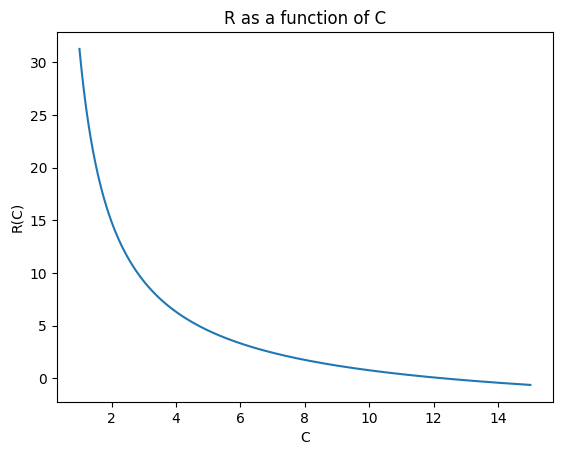

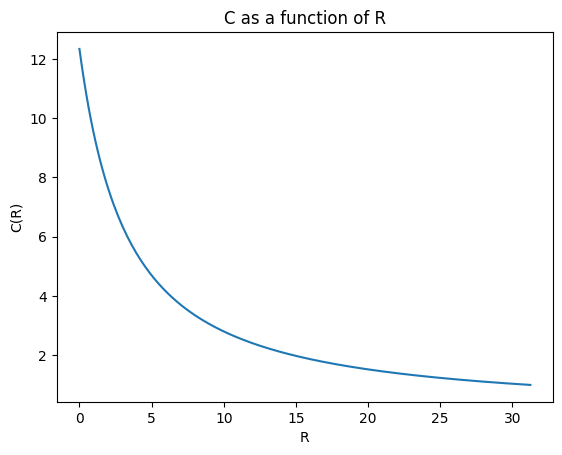

In [58]:
plot_R_and_C([10, 9, 8, 3, 2], 2, k=5,
                 C_min=1,
                 C_max=15.0,
                 num_points=200)

## m-players algorithm

#### Restrited model

In [13]:
# ======================================================
# 1. Zone description / game spec
# ======================================================

@dataclass
class ZoneSpec:
    """
    Specification of a single zone Z_s.

    Attributes
    ----------
    project_indices : List[int]
        Indices (0-based) of projects in this zone.
    active_players : List[int]
        Player indices (0-based) j in J_s.
    """
    project_indices: List[int]
    active_players: List[int]


@dataclass
class RestrictedGMUSpec:
    """
    Specification of a restricted GMU game with fixed zones.

    Attributes
    ----------
    a : np.ndarray, shape (n,)
        Project parameters a_i, sorted nonincreasing (a_0 >= ... >= a_{n-1} > 0).
    total_resources : np.ndarray, shape (m,)
        Total resources r_j for each player j=0..m-1.
    zones : List[ZoneSpec]
        Zone specifications Z_s, s=0..S-1.
    """
    a: np.ndarray
    total_resources: np.ndarray
    zones: List[ZoneSpec]

@dataclass
class HistoryEntry:
    iter_idx: int
    r_zone: np.ndarray      # shape (m, S)
    C_cols: np.ndarray      # shape (S,)
    c_rows: np.ndarray      # shape (m, S)
    R_cols: np.ndarray      # shape (S,)

In [14]:
# ======================================================
# 2. Zone solver: given r_{j,s} (for j in J_s) → C_s, c_{j,s}
# ======================================================

@dataclass
class ZoneSolution:
    C: float                   # cumulative marginal rate C_s
    c_per_player: Dict[int, float]  # c_{j,s} for j in J_s (player index → c-value)


def solve_zone_m(
    a: np.ndarray,
    zone: ZoneSpec,
    r_zone: Dict[int, float],
    tol: float = 1e-10,
    max_iter: int = 200,
) -> ZoneSolution:
    """
    Solve a single zone s with m_s players, given per-player zone resources r_{j,s}.

    Uses the global R_of_C / C_of_R for the zone-specific (a_zone, m_s, k_s, R_s).
    """
    proj_idx = zone.project_indices
    players = zone.active_players

    m_s = len(players)
    if m_s == 0:
        raise ValueError("Zone has no active players.")

    k_s = len(proj_idx)
    if k_s == 0:
        raise ValueError("Zone has no projects.")

    # Zone-specific a_i
    a_zone = a[proj_idx]

    # Column sum R_s = ∑_{j∈J_s} r_{j,s}
    R_s = sum(r_zone.get(j, 0.0) for j in players)
    if R_s < 0:
        raise ValueError("Negative column sum R_s encountered.")

    # --- Solve for C_s using the generic C_of_R ---
    # m_s players, k_s projects, total resource R_s in this zone
    C_s = C_of_R(
        R=R_s,
        a=a_zone,
        m=m_s,
        k=k_s,
        C_low_init=1e-10,
        C_high_init=100.0,
        tol=tol,
        max_iter=max_iter,
    )

    # --- Compute c_{j,s} from beta_{j,s} ---
    # R_s, k_s, m_s, C_s known; for each j:
    denom = m_s * k_s + (m_s - 1.0) * R_s
    c_per_player: Dict[int, float] = {}

    for j in players:
        r_js = r_zone.get(j, 0.0)
        beta_js = (k_s + R_s - r_js) / denom
        c_per_player[j] = beta_js * C_s

    return ZoneSolution(C=C_s, c_per_player=c_per_player)

In [15]:
# ======================================================
# 3. Restricted GMU solver with A/B stages
# ======================================================

@dataclass
class MarginalsResult:
    C_cols: np.ndarray                # shape (S,)
    c_rows: np.ndarray                # shape (m, S), zeros for inactive entries
    r_rows: np.ndarray                # shape (m, S), zeros for inactive entries
    disruptions: np.ndarray           # shape (m,)
    global_disruption: float


class RestrictedGMUSolver:
    """
    Solver for restricted GMU with fixed zones using MU algorithm
    (Stages A and B, with your cross-swaps and self-moves).
    """

    def __init__(self, spec: RestrictedGMUSpec, enable_logging: bool = True):
        self.spec = spec
        self.a = spec.a
        self.r_total = spec.total_resources  # shape (m,)
        self.zones = spec.zones              # list of ZoneSpec
        self.m = len(self.r_total)
        self.S = len(self.zones)

        # Initialize r_zone as an m x S array
        # r_zone[j, s] = resource of player j in zone s (0 if not active)
        self.r_zone = np.zeros((self.m, self.S), dtype=float)

        # History of iterations for visualization
        self.enable_logging = enable_logging
        self.history: List[HistoryEntry] = []

    # ---------------------------
    # Initialization of r_zone
    # ---------------------------

    def initialize_r_zone_uniform(self):
        """
        Simple initializer: for each player j, divide r_j equally
        among the zones where j is active.
        """
        self.r_zone[:] = 0.0
        for j in range(self.m):
            active_zones = [s for s, zone in enumerate(self.zones)
                            if j in zone.active_players]
            if not active_zones:
                continue
            share = self.r_total[j] / len(active_zones)
            for s in active_zones:
                self.r_zone[j, s] = share

    # ---------------------------
    # Marginals
    # ---------------------------

    def compute_marginals(self) -> MarginalsResult:
        """
        From current r_zone, compute C_s and c_{j,s} for all zones and players.

        Returns
        -------
        MarginalsResult
            C_cols[s]         = C_s
            c_rows[j, s]      = c_{j,s} if j active in zone s else 0
            disruptions[j]    = max_s c_{j,s} - min_s c_{j,s} over active zones
            global_disruption = max_j disruptions[j]
        """
        C_cols = np.zeros(self.S, dtype=float)
        c_rows = np.zeros((self.m, self.S), dtype=float)
        r_rows = np.zeros((self.m, self.S), dtype=float)

        for s, zone in enumerate(self.zones):
            # Build r_zone dict for this zone
            r_zone_dict = {j: self.r_zone[j, s] for j in zone.active_players}
            sol = solve_zone_m(self.a, zone, r_zone_dict)
            C_cols[s] = sol.C
            for j, c_js in sol.c_per_player.items():
                c_rows[j, s] = c_js
                r_rows[j, s] = r_zone_dict[j]

        disruptions = np.zeros(self.m, dtype=float)
        for j in range(self.m):
            # active zones for player j
            active_s = [s for s, zone in enumerate(self.zones)
                        if j in zone.active_players]
            if not active_s:
                disruptions[j] = 0.0
                continue
            vals = [c_rows[j, s] for s in active_s]
            disruptions[j] = max(vals) - min(vals)

        global_disruption = float(np.max(disruptions))
        return MarginalsResult(
            C_cols=C_cols,
            c_rows=c_rows,
            r_rows=r_rows,
            disruptions=disruptions,
            global_disruption=global_disruption,
        )

    def _log_state(self, marg: MarginalsResult, iter_idx: int):
        """
        Append current state to history (if logging is enabled).
        """
        if not self.enable_logging:
            return
        # Column sums R_s = ∑_j r_{j,s}
        R_cols = np.sum(self.r_zone, axis=0)

        entry = HistoryEntry(
            iter_idx=iter_idx,
            r_zone=self.r_zone.copy(),
            C_cols=marg.C_cols.copy(),
            c_rows=marg.c_rows.copy(),
            R_cols=R_cols.copy(),
        )
        self.history.append(entry)

    # ---------------------------
    # Stage A: cross-swaps + self-moves
    # ---------------------------

    def step_A(self,
               tol_disruption: float = 1e-6,
               max_inner_iter: int = 1000) -> bool:
        """
        Stage A: try to reduce disruptions using:
          - cross-swaps between different players (preserving column sums),
          - self-moves (one player, right-most zone → another zone).
    
        Moves are accepted only if they strictly reduce global disruption.
    
        Returns
        -------
        changed : bool
            True if at least one modification was performed.
        """
        changed = False
    
        for _ in range(max_inner_iter):
            marg = self.compute_marginals()
            if marg.global_disruption <= tol_disruption:
                return changed
    
            cross_swap_done = self._attempt_cross_swap(marg)
            if cross_swap_done:
                changed = True
                continue  # recompute marginals, keep Stage A going
    
            self_move_done = self._attempt_self_move(marg)
            if self_move_done:
                changed = True
                continue
    
            # If neither cross-swap nor self-move is possible, Stage A is exhausted
            break
    
        return changed


    def _is_disruption_improved(self,
                                marg_old: MarginalsResult,
                                marg_new: MarginalsResult,
                                tol_global: float = 1e-12,
                                tol_sum: float = 1e-12) -> bool:
        """
        Decide whether marg_new is strictly "better" than marg_old.
    
        Lexicographic criterion:
          1) If global_disruption_new < global_disruption_old - tol_global -> improved.
          2) Else if |global_new - global_old| <= tol_global AND
                    sum(disruptions_new) < sum(disruptions_old) - tol_sum -> improved.
          3) Otherwise -> not improved.
    
        This lets us accept moves that keep the global max spread the same but
        reduce the overall sum of spreads across players.
        """
        g_old = float(marg_old.global_disruption)
        g_new = float(marg_new.global_disruption)
    
        if g_new < g_old - tol_global:
            return True
    
        if abs(g_new - g_old) <= tol_global:
            sum_old = float(np.sum(marg_old.disruptions))
            sum_new = float(np.sum(marg_new.disruptions))
            if sum_new < sum_old - tol_sum:
                return True
    
        return False

    def _attempt_cross_swap(self,
                            marg: MarginalsResult,
                            tol_global: float = 1e-12,
                            tol_sum: float = 1e-12,
                            max_backtracking: int = 10) -> bool:
        """
        Scan all players and zone pairs for a cross-swap opportunity:

        Find j, i, k, ℓ such that:
          - j, i are active in both zones k and ℓ,
          - c_{j,k} > c_{j,ℓ} and c_{i,k} < c_{i,ℓ}  (opposite sign).

        Then try to perform a cross-swap:

            r_{j,k} += τ, r_{j,ℓ} -= τ
            r_{i,k} -= τ, r_{i,ℓ} += τ

        with backtracking on τ, accepting if the disruptions (global + sum) improve.
        """
        c_rows = marg.c_rows

        for j in range(self.m):
            # zones where j is active
            active_s_j = [s for s, zone in enumerate(self.zones)
                          if j in zone.active_players]
            if len(active_s_j) < 2:
                continue

            for k in active_s_j:
                for ℓ in active_s_j:
                    if k == ℓ:
                        continue
                    diff_j = c_rows[j, k] - c_rows[j, ℓ]
                    if diff_j <= 0:
                        continue

                    # look for i with opposite sign on same pair (k, ℓ)
                    for i in range(self.m):
                        if i == j:
                            continue
                        if not (i in self.zones[k].active_players and
                                i in self.zones[ℓ].active_players):
                            continue

                        diff_i = c_rows[i, k] - c_rows[i, ℓ]
                        if diff_i >= 0:
                            continue

                        # candidate (j, i, k, ℓ)
                        max_tau = min(self.r_zone[j, ℓ], self.r_zone[i, k])
                        if max_tau <= 0:
                            continue

                        tau = max_tau
                        for _ in range(max_backtracking):
                            r_old = self.r_zone.copy()

                            # tentative move
                            self.r_zone[j, k] += tau
                            self.r_zone[j, ℓ] -= tau
                            self.r_zone[i, k] -= tau
                            self.r_zone[i, ℓ] += tau

                            marg_new = self.compute_marginals()
                            if self._is_disruption_improved(marg, marg_new,
                                                       tol_global=tol_global,
                                                       tol_sum=tol_sum):
                                # good move
                                return True

                            # revert and shrink step
                            self.r_zone = r_old
                            tau *= 0.5
                            if tau < 1e-12:
                                break

            return False

    def _attempt_self_move(self,
                           marg: MarginalsResult,
                           tol_global: float = 1e-12,
                           tol_sum: float = 1e-12,
                           max_backtracking: int = 10) -> bool:
        """
        Attempt a self-move for a single player j with nonzero disruption:

          - Pick j* with largest disruption.
          - For j*, pick right-most active zone with positive resource.
          - Move resource τ from that right-most zone to the zone that best
            flattens row j*, accepting if disruptions improve (global+sum).
        """
        disruptions = marg.disruptions
        c_rows = marg.c_rows

        # pick player j* with largest disruption
        j_star = int(np.argmax(disruptions))
        if disruptions[j_star] <= 0:
            return False

        active_s = [s for s, zone in enumerate(self.zones)
                    if j_star in zone.active_players]
        if len(active_s) < 2:
            return False

        positive_s = [s for s in active_s if self.r_zone[j_star, s] > 0]
        if not positive_s:
            return False
        s_right = max(positive_s)

        # c-values for j*
        c_vals = [(s, c_rows[j_star, s]) for s in active_s]
        s_min = min(c_vals, key=lambda x: x[1])[0]
        s_max = max(c_vals, key=lambda x: x[1])[0]

        if c_rows[j_star, s_right] > c_rows[j_star, s_min]:
            s_target = s_min  # from high c to low c
        elif c_rows[j_star, s_right] < c_rows[j_star, s_max]:
            s_target = s_max  # from low c to high c
        else:
            return False

        max_tau = self.r_zone[j_star, s_right]
        if max_tau <= 0:
            return False

        tau = max_tau
        for _ in range(max_backtracking):
            r_old = self.r_zone.copy()

            # tentative move: s_right -> s_target
            self.r_zone[j_star, s_right] -= tau
            self.r_zone[j_star, s_target] += tau

            marg_new = self.compute_marginals()
            if self._is_disruption_improved(marg, marg_new,
                                       tol_global=tol_global,
                                       tol_sum=tol_sum):
                return True

            self.r_zone = r_old
            tau *= 0.5
            if tau < 1e-12:
                break

        return False
    
    def step_B(
        self,
        tol_row_improve: float = 1e-9,
        tol_global_increase: float = 1e-9,
        max_backtracking: int = 15,
    ) -> bool:
        """
        Stage B: change column sums R_s to reduce disruptions.
    
        New acceptance rule:
          - For a candidate column s and participant set J ⊆ players active in s:
            * For each j ∈ J, we find a donor column l(j) with
                  c_{j,s} > c_{j,l(j)} and r_{j,l(j)} > 0
              (strictly lower marginal and positive resource).
            * We try to move epsilon from l(j) -> s for all j ∈ J.
          - A tentative move is accepted if:
              (1) For all j ∈ J, their row spread strictly decreases
                  by at least tol_row_improve, AND
              (2) The new global disruption is ≤ old global_disruption + tol_global_increase.
    
        This allows us to flatten the rows that actually "see" s as too high,
        even if the global max spread doesn't immediately drop, as long as we
        don't blow up global disruption.
        """
        # Current marginals and disruptions
        marg_old = self.compute_marginals()
        c_rows_old = marg_old.c_rows
        d_old = float(marg_old.global_disruption)
        disruptions_old = marg_old.disruptions.copy()
    
        if d_old <= 0.0:
            return False
    
        m = self.m
        S = self.S
    
        # Helper: per-player spread over active zones
        def row_spread(j: int, marg: MarginalsResult) -> float:
            vals = []
            for s, zone in enumerate(self.zones):
                if j in zone.active_players:
                    vals.append(marg.c_rows[j, s])
            if not vals:
                return 0.0
            return max(vals) - min(vals)
    
        # Try each column s as candidate "too high" column
        for s in range(S):
            zone_s = self.zones[s]
    
            # 1) Build participant set J and donor columns L(j)
            J = []
            L = {}
            for j in zone_s.active_players:
                best_l = None
                best_c = None
                c_js = c_rows_old[j, s]
    
                # Scan all other columns where j is active with positive resource
                for l in range(S):
                    if l == s:
                        continue
                    zone_l = self.zones[l]
                    if j not in zone_l.active_players:
                        continue
                    if self.r_zone[j, l] <= 0.0:
                        continue
    
                    c_jl = c_rows_old[j, l]
                    if c_jl < c_js - 1e-12:  # strictly lower marginal
                        if (best_l is None) or (c_jl < best_c):
                            best_l = l
                            best_c = c_jl
    
                if best_l is not None:
                    J.append(j)
                    L[j] = best_l
    
            if not J:
                # No player sees column s as strictly too high relative to some donor
                continue
    
            # 2) We have a B-candidate for column s with players J
            # Max epsilon dictated by non-negativity in donor columns
            max_eps = min(self.r_zone[j, L[j]] for j in J)
            if max_eps <= 0.0:
                continue
    
            # Precompute old spreads for rows in J
            spreads_old_J = {j: row_spread(j, marg_old) for j in J}
    
            eps = max_eps
            for _ in range(max_backtracking):
                r_old = self.r_zone.copy()
    
                # Tentative move: for all j in J, move eps from l(j) -> s
                for j in J:
                    l = L[j]
                    self.r_zone[j, s] += eps
                    self.r_zone[j, l] -= eps
    
                marg_new = self.compute_marginals()
                d_new = float(marg_new.global_disruption)
    
                # New spreads for J
                spreads_new_J = {j: row_spread(j, marg_new) for j in J}
    
                # Acceptance conditions:
                #  (1) For all j ∈ J, spread_new < spread_old - tol_row_improve
                #  (2) d_new <= d_old + tol_global_increase
                all_improved = True
                for j in J:
                    if spreads_new_J[j] >= spreads_old_J[j] - tol_row_improve:
                        all_improved = False
                        break
    
                if all_improved and (d_new <= d_old + tol_global_increase):
                    # Accept this B-move
                    return True
    
                # Otherwise revert and shrink eps
                self.r_zone = r_old
                eps *= 0.5
                if eps < 1e-12:
                    break
    
        # No B-move found that improves the participating rows without
        # blowing up global disruption
        return False
    # ---------------------------
    # Main run loop
    # ---------------------------

    def run(
        self,
        tol_disruption: float = 1e-6,
        max_outer_iter: int = 100,
    ) -> MarginalsResult:
        """
        Run the MU algorithm (Stages A and B) to approximate a restricted Nash
        equilibrium for the given fixed-zone game.

        Returns
        -------
        MarginalsResult
            Marginals and disruptions at the final state.
        """
        for outer in range(max_outer_iter):
            marg = self.compute_marginals()
            self._log_state(marg, iter_idx=outer)

            if marg.global_disruption <= tol_disruption:
                return marg

            changed_A = self.step_A(tol_disruption=tol_disruption)
            if changed_A:
                continue

            changed_B = self.step_B()
            if not changed_B:
                # No A or B move possible → we’re stuck; return current state
                return marg

        marg = self.compute_marginals()
        self._log_state(marg, iter_idx=max_outer_iter)
        return marg

#### Global NE

In [16]:
def enumerate_k_configurations(m: int, n: int) -> List[List[int]]:
    """
    Enumerate all admissible cutoff vectors k = (k1,...,km)
    with 1 <= k_m <= ... <= k_1 <= n.

    Returns
    -------
    configs : list[list[int]]
        Each element is [k1, ..., km].
    """
    configs = []
    cur = [1] * m  # will store k_m, ..., k_1 in nondecreasing order

    def backtrack(pos: int, last_val: int):
        # pos runs from 0..m-1, building k_m..k_1
        if pos == m:
            # cur = [k_m, ..., k_1], reverse to get [k1, ..., km]
            k_vec = cur[::-1]
            configs.append(k_vec)
            return
        for v in range(last_val, n + 1):
            cur[pos] = v
            backtrack(pos + 1, v)

    backtrack(0, 1)
    return configs

In [17]:
def build_zones_from_k(k: List[int], m: int, n: int) -> List[ZoneSpec]:
    """
    Given a cutoff vector k = [k1,...,km], build the corresponding zones.

    Semantics:
    ----------
    - Projects are indexed i = 0,...,n-1.
    - Player j is allowed to invest in projects i with i+1 <= k[j]
      (i.e. the first k[j] projects in 1-based indexing).
    - For each project i, the active set is:
          active(i) = { j : k[j] >= i+1 }.
    - Consecutive projects with identical active(i) form one zone.
    - Projects with active(i) = ∅ are *not* included in any zone.
    """
    zones: List[ZoneSpec] = []
    current_players = None
    start = None  # start index of current zone

    for i in range(n):
        # players are 0..m-1, k[j] is 1-based cutoff
        active = [j for j in range(m) if k[j] >= (i + 1)]

        if active:
            # This project has some active players
            if current_players is None:
                # Start first zone
                current_players = active
                start = i
            elif active != current_players:
                # Close the previous zone [start, i)
                zones.append(ZoneSpec(
                    project_indices=list(range(start, i)),
                    active_players=current_players,
                ))
                # Start a new zone at i
                current_players = active
                start = i
        else:
            # No active players on this project
            if current_players is not None:
                # Close the previous zone [start, i)
                zones.append(ZoneSpec(
                    project_indices=list(range(start, i)),
                    active_players=current_players,
                ))
                current_players = None
                start = None
            # Then we just skip this project entirely

    # Close last zone if still open at the end
    if current_players is not None and start is not None:
        zones.append(ZoneSpec(
            project_indices=list(range(start, n)),
            active_players=current_players,
        ))

    return zones

In [18]:
def allocate_within_zone(
    a: np.ndarray,
    zone,
    r_zone_s: Dict[int, float],
    C_s: float,
    c_per_player_s: Dict[int, float] | None = None,
    clamp_negative: bool = True,
    tol: float = 1e-10,
) -> Dict[int, np.ndarray]:
    """
    Given a fixed zone, its cumulative marginal C_s, and the resources r_{j,s}
    of each active player in that zone, compute the *per-project* allocations
    x_{j,i} inside the zone.

    Parameters
    ----------
    a : np.ndarray, shape (n,)
        Global project parameters a_1 >= ... >= a_n > 0.
    zone : ZoneSpec-like
        Must have:
          - zone.project_indices : list[int] of global project indices in this zone
          - zone.active_players  : list[int] of player indices active in this zone.
    r_zone_s : dict[int, float]
        Mapping j -> r_{j,s}, each active player's resource in this zone.
    C_s : float
        Zone-level cumulative marginal for this zone (what solve_zone_m returned).
    c_per_player_s : dict[int, float] or None
        Not used here, kept for backwards compatibility with existing calls.
    clamp_negative : bool
        If True, clamp tiny negative x_{j,i} to 0.
    tol : float
        Tolerance for optional resource consistency checks.

    Returns
    -------
    x_zone : dict[int, np.ndarray]
        For each active player j, a 1D array x_zone[j] of length k (k projects
        in this zone), giving x_{j,i} for i in zone.project_indices (same order).
    """
    proj_idx = list(zone.project_indices)
    k = len(proj_idx)
    players = list(zone.active_players)
    m_zone = len(players)

    # If there are no projects, return empty arrays (this is safe: caller
    # will also see proj_idx == [], so no assignment happens).
    if k == 0 or m_zone == 0:
        return {j: np.zeros(0, dtype=float) for j in players}

    a_zone = np.asarray(a[proj_idx], dtype=float)

    # Total resource in this zone
    R_s = sum(float(r_zone_s.get(j, 0.0)) for j in players)

    # If no resource or nonpositive C_s, treat as zero allocation but with
    # correct length k to avoid shape mismatches.
    if R_s <= 0.0 or C_s <= 0.0:
        return {j: np.zeros(k, dtype=float) for j in players}

    # -------------------------------------------------
    # 1) Compute L_i in this zone
    #
    # Consistent with our earlier R_of_C:
    #
    #   R + k = (1/C_s) * Σ_i a_i [ (m-1)/2 + sqrt((m-1)^2/4 + C_s / a_i) ]
    #
    # If we define
    #
    #   S_i = a_i [ (m-1)/2 + sqrt((m-1)^2/4 + C_s / a_i) ]
    #
    # then R + k = (1/C_s) Σ_i S_i, so we can set
    #
    #   L_i := S_i / C_s
    #
    # and Σ_i L_i = R + k = Σ_i (1 + Σ_j x_{j,i}).
    # -------------------------------------------------
    m1 = float(m_zone - 1)
    L = np.empty(k, dtype=float)

    for idx in range(k):
        ai = a_zone[idx]
        inner = (m1 * m1) / 4.0 + C_s / ai
        # numerical safety
        if inner < 0.0:
            inner = 0.0
        S_i = ai * (m1 / 2.0 + np.sqrt(inner))
        L[idx] = S_i / C_s

    # S1 = Σ_i L_i
    S1 = float(np.sum(L))

    # -------------------------------------------------
    # 2) Define S2 = Σ_i L_i^2 / a_i
    #
    # From FOC we have, for each player j and each project i in the zone:
    #
    #   c_j = a_i (L_i - x_{j,i}) / L_i^2
    #   => x_{j,i} = L_i - c_j L_i^2 / a_i
    #
    # and resource constraint:
    #
    #   r_j = Σ_i x_{j,i} = S1 - c_j S2,
    #
    # where S2 = Σ_i L_i^2 / a_i.
    #
    # So c_j = (S1 - r_j) / S2.
    # -------------------------------------------------
    S2 = float(np.sum(L * L / a_zone))

    # Degenerate guard: if S2 is tiny, just return zeros (should not happen
    # in a well-posed zone).
    if S2 <= 0.0:
        return {j: np.zeros(k, dtype=float) for j in players}

    x_zone: Dict[int, np.ndarray] = {}

    for j in players:
        rj = float(r_zone_s.get(j, 0.0))

        # c_j in this zone
        c_j = (S1 - rj) / S2

        # x_{j,i} = L_i - c_j * L_i^2 / a_i
        x_j = L - c_j * (L * L / a_zone)

        if clamp_negative:
            # clamp small negatives caused by numerical error
            x_j[x_j < 0.0] = 0.0

        # Optional consistency check: sum_i x_{j,i} ≈ r_j
        if abs(np.sum(x_j) - rj) > 10 * tol:
            # you can turn this into a warning or assertion as you prefer
            # for now, we just leave it; the solver's zone resources
            # themselves may still be adjusting.
            pass

        x_zone[j] = x_j

    return x_zone

In [19]:
def compute_full_allocation_from_solver(
    solver: "RestrictedGMUSolver",
    marg: "MarginalsResult",
    a: np.ndarray,
) -> np.ndarray:
    """
    Compute per-project allocations X[j, i] for all players and projects
    from a RestrictedGMUSolver and its final marginals.

    Parameters
    ----------
    solver : RestrictedGMUSolver
        Must have .zones and .r_zone (m x S).
    marg : MarginalsResult
        Must have .C_cols (S,) and .c_rows (m x S).
    a : np.ndarray, shape (n,)
        Project parameters.

    Returns
    -------
    X : np.ndarray, shape (m, n)
        X[j, i] = x_{j,i}, allocation of player j to project i.
        Projects with no active players get zeros in that column.
    """
    a = np.asarray(a, dtype=float)
    n = len(a)

    m = solver.m
    S = solver.S
    zones = solver.zones
    r_zone = solver.r_zone
    C_cols = marg.C_cols
    c_rows = marg.c_rows

    X = np.zeros((m, n), dtype=float)

    for s, zone in enumerate(zones):
        proj_idx = zone.project_indices
        active_players = zone.active_players

        # Gather r_{j,s} and c_{j,s} for this zone
        r_zone_s = {j: r_zone[j, s] for j in active_players}
        c_per_player_s = {j: c_rows[j, s] for j in active_players}
        C_s = C_cols[s]

        x_zone = allocate_within_zone(a, zone, r_zone_s, C_s, c_per_player_s)

        # Write into global X
        for j in active_players:
            # x_zone[j] is aligned with proj_idx
            X[j, np.array(proj_idx)] = x_zone[j]

    return X

In [20]:
def compute_true_bc_penalty(
    solver: "RestrictedGMUSolver",
    marg: "MarginalsResult",
    a: np.ndarray,
    X: np.ndarray,
    active_tol: float = 1e-10,
) -> tuple[float, np.ndarray]:
    """
    Compute BC violation using the *true* derivative at 0 for each player j
    and their actual investments X[j,i], but using the marginal in the
    *last active zone* of that player (not an average across zones).

    Parameters
    ----------
    solver : RestrictedGMUSolver
        Has .zones (list[ZoneSpec]) and .S, .m.
    marg : MarginalsResult
        Has c_rows[j,s].
    a : np.ndarray, shape (n,)
        Project parameters.
    X : np.ndarray, shape (m, n)
        Per-project allocations X[j,i].
    active_tol : float
        Threshold to consider x_{j,i} as "positive" (active).

    Returns
    -------
    bc_penalty : float
        Max BC violation over players.
    bc_by_player : np.ndarray, shape (m,)
        Per-player BC violations.
    """
    a = np.asarray(a, dtype=float)
    n = len(a)
    c_rows = marg.c_rows
    zones = solver.zones
    S = solver.S
    m, nX = X.shape
    assert nX == n

    # Precompute a map: for each project i, which zone s it belongs to
    proj_to_zone = [-1] * n
    for s, zone in enumerate(zones):
        for i in zone.project_indices:
            proj_to_zone[i] = s

    bc_by_player = np.zeros(m, dtype=float)

    for j in range(m):
        # Set of projects where player j actually invests
        active_proj = [i for i in range(n) if X[j, i] > active_tol]
        if not active_proj:
            # Player j invests nowhere; for now, treat BC as 0
            bc_by_player[j] = 0.0
            continue

        # Last project (highest index) where j invests
        k_j = max(active_proj)
        if k_j >= n - 1:
            # No boundary project after k_j
            bc_by_player[j] = 0.0
            continue

        boundary_i = k_j + 1

        # Find zone s_last containing the last active project k_j
        s_last = proj_to_zone[k_j]
        if s_last < 0:
            # Should not happen if zones are built correctly
            bc_by_player[j] = 0.0
            continue

        # Marginal for player j in their *last active zone*
        c_j_last = c_rows[j, s_last]

        # Total load from other players on boundary project
        L_minus_j = np.sum(X[:, boundary_i]) - X[j, boundary_i]

        # Derivative at 0 for player j at boundary project:
        deriv_boundary = a[boundary_i] / (1.0 + L_minus_j)

        violation = max(0.0, deriv_boundary - c_j_last)
        bc_by_player[j] = violation

    bc_penalty = float(np.max(bc_by_player))
    return bc_penalty, bc_by_player

In [21]:
@dataclass
class RestrictedGMUSpec:
    a: np.ndarray
    total_resources: np.ndarray
    zones: List[ZoneSpec]
    
def run_mug_restricted_for_k(
    a,
    r_players,
    k: List[int],
    max_iter: int = 500,
    tol_row: float = 1e-6,
    enable_logging: bool = False,
):
    """
    Build zones from k, run RestrictedGMUSolver, then compute full X and true BC.
    """
    a = np.asarray(a, dtype=float)
    r_players = np.asarray(r_players, dtype=float)
    n = len(a)
    m = len(r_players)

    k = list(k)
    if len(k) != m:
        raise ValueError("Length of k must match number of players.")

    # 1) build zones from k
    zones = build_zones_from_k(k, m=m, n=n)
    if len(zones) == 0:
        raise ValueError("No zones generated from k; check k.")

    spec = RestrictedGMUSpec(
        a=a,
        total_resources=r_players,
        zones=zones,
    )

    solver = RestrictedGMUSolver(spec, enable_logging=enable_logging)
    solver.initialize_r_zone_uniform()

    # 2) run A/B
    marg = solver.run(
        tol_disruption=tol_row,
        max_outer_iter=max_iter,
    )

    d_rows = marg.global_disruption

    # 3) full allocation X[j,i]
    X = compute_full_allocation_from_solver(solver, marg, a)

    # 4) true BC penalty
    bc_penalty, bc_by_player = compute_true_bc_penalty(solver, marg, a, X)

    return solver, marg, X, d_rows, bc_penalty, bc_by_player

In [22]:
@dataclass
class GlobalFrame:
    step_idx: int             # k-step index in the greedy loop
    k: List[int]              # current cutoff vector
    zones: List["ZoneSpec"]   # zones for this k
    entry: "HistoryEntry"     # one snapshot from solver.history

In [23]:
def find_global_NE_by_k_search(
    a,
    r_players,
    max_iter_inner: int = 500,
    tol_row_inner: float = 1e-6,
    bc_tol_equiv: float = 1e-8,
    verbose: bool = True,
    max_k_steps: int | None = None,
    record_mode: str | None = None,   # NEW: None | "between" | "full"
):
    """
    Greedy global NE search over k, guided by boundary-condition violations.

    Instead of enumerating all k-configurations, we:
      - start from k = [1, 1, ..., 1],
      - for each k:
          * run the restricted MU solver (A/B),
          * compute true BC penalty + per-player BC violations,
          * if BC and disruption are both small -> stop,
          * else expand the zone (increase k_j by 1) for the player j
            with the largest BC violation, subject to:
                - k_j < n
                - monotonicity k_1 >= k_2 >= ... >= k_m is preserved.

    NEW:
      - record_mode:
          * None      : no visualization data collected
          * "between" : one frame per k (final A/B state only)
          * "full"    : all A/B iterations from solver.history per k

    Returns
    -------
    best_solver : RestrictedGMUSolver
    best_marg   : MarginalsResult
    best_k      : list[int]
    best_bc_penalty : float
    best_disruption : float
    X_best      : np.ndarray, shape (m, n)
    global_frames : list[GlobalFrame]
        Frames for visualization (may be empty if record_mode is None).
    """
    a = np.asarray(a, dtype=float)
    r_players = np.asarray(r_players, dtype=float)
    n = len(a)
    m = len(r_players)

    if max_k_steps is None:
        max_k_steps = m * n

    # Initial k: everyone can invest only in project 1
    k = [1] * m

    visited = set()
    visited.add(tuple(k))

    best_solver = None
    best_marg = None
    best_k = k.copy()
    best_bc_penalty = np.inf
    best_disruption = np.inf
    X_best = None

    # NEW: list of frames for visualization
    global_frames: list[GlobalFrame] = []

    for step in range(max_k_steps):
        if verbose:
            print(f"\n=== k-step {step+1}/{max_k_steps} ===")
            print("Current k:", k)

        # 1) Solve restricted game for this k
        solver, marg, X, d_rows, bc_penalty, bc_by_player = run_mug_restricted_for_k(
            a,
            r_players,
            k,
            max_iter=max_iter_inner,
            tol_row=tol_row_inner,
            enable_logging=(record_mode is not None),  # <--- NEW
        )

        # --- NEW: record visualization frames ---
        if record_mode is not None:
            zones = build_zones_from_k(k, m=m, n=n)

            if record_mode == "between":
                # only final state for this k
                if solver.history:
                    entry = solver.history[-1]
                    global_frames.append(
                        GlobalFrame(
                            step_idx=step,
                            k=k.copy(),
                            zones=zones,
                            entry=entry,
                        )
                    )
            elif record_mode == "full":
                # all A/B sub-iterations
                for entry in solver.history:
                    global_frames.append(
                        GlobalFrame(
                            step_idx=step,
                            k=k.copy(),
                            zones=zones,
                            entry=entry,
                        )
                    )

        if verbose:
            print(f"  BC penalty = {bc_penalty:.6e}, disruption = {d_rows:.6e}")
            print(f"  BC by player = {bc_by_player}")
            print(f"  Rates matrix = {marg.c_rows}")
            print(f"  Investments matrix = {X}")

        # 2) Update best-so-far (lexicographic: BC, then disruption)
        if bc_penalty + bc_tol_equiv < best_bc_penalty:
            best_bc_penalty = bc_penalty
            best_disruption = d_rows
            best_solver = solver
            best_marg = marg
            best_k = k.copy()
            X_best = X.copy()
        elif abs(bc_penalty - best_bc_penalty) <= bc_tol_equiv and d_rows < best_disruption:
            best_disruption = d_rows
            best_solver = solver
            best_marg = marg
            best_k = k.copy()
            X_best = X.copy()

        # 3) Stopping criterion: BC small AND row disruption small
        if bc_penalty <= bc_tol_equiv and d_rows <= tol_row_inner:
            if verbose:
                print("BC and row disruption both within tolerance; stopping.")
            break

        # 4) Choose which player's zone to expand based on BC violations
        bc_by_player = np.asarray(bc_by_player, dtype=float)

        candidates = []
        for j in range(m):
            if bc_by_player[j] <= 0.0:
                continue
            if k[j] >= n:
                continue
            # monotonicity: k[0] >= k[1] >= ... >= k[m-1]
            if j > 0 and k[j] + 1 > k[j - 1]:
                continue

            new_k = list(k)
            new_k[j] += 1
            if tuple(new_k) in visited:
                continue

            candidates.append(j)

        if not candidates:
            if verbose:
                print("No players can be expanded (monotonicity / n bound); stopping.")
            break

        # Player with largest BC violation among candidates
        j_star = max(candidates, key=lambda J: bc_by_player[J])

        if verbose:
            print(
                f"  Expanding player j={j_star} from k_j={k[j_star]} "
                f"to k_j={k[j_star] + 1}"
            )

        # 5) Apply expansion
        k[j_star] += 1
        visited.add(tuple(k))

    if best_solver is None or best_marg is None or X_best is None:
        raise RuntimeError("Greedy NE search failed to find any feasible configuration.")

    if verbose:
        print("\n=== Greedy global NE search over k (BC-guided) ===")
        print("Final best k:", best_k)
        print("Final best BC penalty:", best_bc_penalty)
        print("Final best row disruption:", best_disruption)

    return best_solver, best_marg, best_k, best_bc_penalty, best_disruption, X_best, global_frames

In [24]:
a = np.array([15, 7, 5, 4, 3, 2, 1], dtype=float)
r_total = np.array([40.0, 6.0, 3.0, 1.0], dtype=float)

a = np.array([12, 11, 3, 2, 1, 0.1], dtype=float)
r_total = np.array([100, 8, 7, 1], dtype=float)

best_solver, best_marg, best_k, best_bc, best_disrupt, X_best, global_frames = find_global_NE_by_k_search(
    a,
    r_total,
    max_iter_inner=500,
    tol_row_inner=1e-6,
    verbose=True,
)

print("Chosen k:", best_k)
print("Final r_zone:\n", best_solver.r_zone)
print("Final c_rows:\n", best_marg.c_rows)
print("Final project investments:\n", X_best)


=== k-step 1/24 ===
Current k: [1, 1, 1, 1]
  BC penalty = 1.098510e+01, disruption = 0.000000e+00
  BC by player = [10.98509752 10.90444883 10.90357221 10.89831251]
  Rates matrix = [[0.01490248]
 [0.09555117]
 [0.09642779]
 [0.10168749]]
  Investments matrix = [[100.   0.   0.   0.   0.   0.]
 [  8.   0.   0.   0.   0.   0.]
 [  7.   0.   0.   0.   0.   0.]
 [  1.   0.   0.   0.   0.   0.]]
  Expanding player j=0 from k_j=1 to k_j=2

=== k-step 2/24 ===
Current k: [2, 1, 1, 1]
  BC penalty = 2.977754e+00, disruption = 1.000001e-06
  BC by player = [2.97775402 0.37983672 0.37852819 0.37067702]
  Rates matrix = [[0.02224498 0.02224598]
 [0.11484075 0.        ]
 [0.11614928 0.        ]
 [0.12400045 0.        ]]
  Investments matrix = [[78.76328903 21.23671097  0.          0.          0.          0.        ]
 [ 8.          0.          0.          0.          0.          0.        ]
 [ 7.          0.          0.          0.          0.          0.        ]
 [ 1.          0.          0.  

#### Visualization for m-players algorithm

In [25]:
def plot_c_history(solver: RestrictedGMUSolver,
                   players: Optional[List[int]] = None,
                   zones: Optional[List[int]] = None):
    """
    Plot c_{j,s} over iterations for selected players / zones.

    Parameters
    ----------
    players : list of ints or None
        Player indices to plot (0-based). If None, plot all players.
    zones : list of ints or None
        Zone indices to plot. If None, plot all zones.
    """
    if not solver.history:
        raise ValueError("No history recorded. Run solver.run() first with logging enabled.")

    m = solver.m
    S = solver.S

    if players is None:
        players = list(range(m))
    if zones is None:
        zones = list(range(S))

    iters = [h.iter_idx for h in solver.history]

    for j in players:
        plt.figure()
        for s in zones:
            c_js = [h.c_rows[j, s] for h in solver.history]
            plt.plot(iters, c_js, label=f"zone {s + 1}")
        plt.xlabel("iteration")
        plt.ylabel(f"c_j,s for player {j + 1}")
        plt.title(f"Marginal rates c_j,s over iterations (player {j + 1})")
        plt.legend()
        plt.tight_layout()

In [26]:
def plot_r_history(solver: RestrictedGMUSolver,
                   players: Optional[List[int]] = None,
                   zones: Optional[List[int]] = None):
    """
    Plot r_{j,s} over iterations for selected players / zones.
    """
    if not solver.history:
        raise ValueError("No history recorded. Run solver.run() first with logging enabled.")

    m = solver.m
    S = solver.S

    if players is None:
        players = list(range(m))
    if zones is None:
        zones = list(range(S))

    iters = [h.iter_idx for h in solver.history]

    for j in players:
        plt.figure()
        for s in zones:
            r_js = [h.r_zone[j, s] for h in solver.history]
            plt.plot(iters, r_js, label=f"zone {s + 1}")
        plt.xlabel("iteration")
        plt.ylabel(f"r_j,s for player {j + 1}")
        plt.title(f"Resources r_j,s over iterations (player {j + 1})")
        plt.legend()
        plt.tight_layout()

In [27]:
def plot_R_C_history(solver: RestrictedGMUSolver,
                     zones: Optional[List[int]] = None):
    """
    Plot column sums R_s and cumulative marginal rates C_s over iterations.
    """
    if not solver.history:
        raise ValueError("No history recorded. Run solver.run() first with logging enabled.")

    S = solver.S
    if zones is None:
        zones = list(range(S))

    iters = [h.iter_idx for h in solver.history]

    # Plot R_s
    plt.figure()
    for s in zones:
        R_s = [h.R_cols[s] for h in solver.history]
        plt.plot(iters, R_s, label=f"R_{s + 1}")
    plt.xlabel("iteration")
    plt.ylabel("R_s")
    plt.title("Column resources R_s over iterations")
    plt.legend()
    plt.tight_layout()

    # Plot C_s
    plt.figure()
    for s in zones:
        C_s = [h.C_cols[s] for h in solver.history]
        plt.plot(iters, C_s, label=f"C_{s + 1}")
    plt.xlabel("iteration")
    plt.ylabel("C_s")
    plt.title("Cumulative marginal rates C_s over iterations")
    plt.legend()
    plt.tight_layout()

In [28]:
def animate_c_heatmap(solver: RestrictedGMUSolver,
                      interval: int = 500):
    """
    Create a matplotlib animation showing c_{j,s} as a heatmap over iterations.

    Returns
    -------
    ani : matplotlib.animation.FuncAnimation
        You can display it in Jupyter with HTML(ani.to_jshtml()).
    """
    if not solver.history:
        raise ValueError("No history recorded. Run solver.run() first with logging enabled.")

    m = solver.m
    S = solver.S

    fig, ax = plt.subplots()
    c0 = solver.history[0].c_rows
    im = ax.imshow(c0, aspect='auto', origin='lower')
    ax.set_xlabel("zone s")
    ax.set_ylabel("player j")
    ax.set_title("c_{j,s} over iterations")

    def update(frame_idx):
        entry = solver.history[frame_idx]
        im.set_data(entry.c_rows)
        ax.set_title(f"c_{j,s}, iteration {entry.iter_idx}")
        return [im]

    ani = FuncAnimation(fig, update, frames=len(solver.history),
                        interval=interval, blit=True)
    return ani

#### Solving a resticted game

In [29]:
a = np.array([15, 7, 5, 4, 3, 2, 1], dtype=float)
r_total = np.array([40.0, 6.0, 3.0, 1.0], dtype=float)
zones = [
    ZoneSpec(
        project_indices=[0, 1],        
        active_players=[0, 1, 2, 3] 
    ),
    ZoneSpec(
        project_indices=[2, 3, 4],  
        active_players=[0, 1, 2]
    ),
    ZoneSpec(
        project_indices=[5],
        active_players=[0, 1]
    ),
    ZoneSpec(
        project_indices=[6],
        active_players=[0]
    ),
]

spec = RestrictedGMUSpec(
    a=a,
    total_resources=r_total,
    zones=zones,
)

# --- 3. Build solver, initialize, run ---

solver = RestrictedGMUSolver(spec)
solver.initialize_r_zone_uniform()   # each player splits r_j equally across zones where active

final_marg = solver.run(
    tol_disruption=1e-6,
    max_outer_iter=2000,
)

print("Final global disruption:", final_marg.global_disruption)
print()

# r_zone[j, s]: resources of player j in zone s
print("Final r_zone (rows = players, cols = zones):")
print(solver.r_zone)
print()

# c_rows[j, s]: marginal rates c_{j,s} in final state
print("Final c_rows (rows = players, cols = zones):")
print(final_marg.c_rows)
print()

# Column-level info
R_cols = np.sum(solver.r_zone, axis=0)
print("Final R_s (column sums):", R_cols)
print("Final C_s:", final_marg.C_cols)

Final global disruption: 0.0032687284418995155

Final r_zone (rows = players, cols = zones):
[[23.36836584 13.07435736  2.2697356   1.28754121]
 [ 4.11165705  1.80983297  0.07850998  0.        ]
 [ 2.32196612  0.67803388  0.          0.        ]
 [ 1.          0.          0.          0.        ]]

Final c_rows (rows = players, cols = zones):
[[0.19287498 0.19108775 0.19240642 0.19110064]
 [0.58658768 0.58331896 0.58332155 0.        ]
 [0.62317878 0.62272825 0.         0.        ]
 [0.65020701 0.         0.         0.        ]]

Final R_s (column sums): [30.80198902 15.56222421  2.34824557  1.28754121]
Final C_s: [2.05284845 1.39713495 0.77572797 0.19110064]


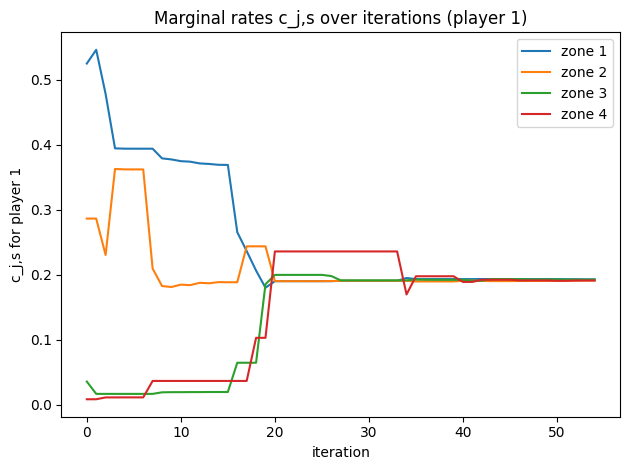

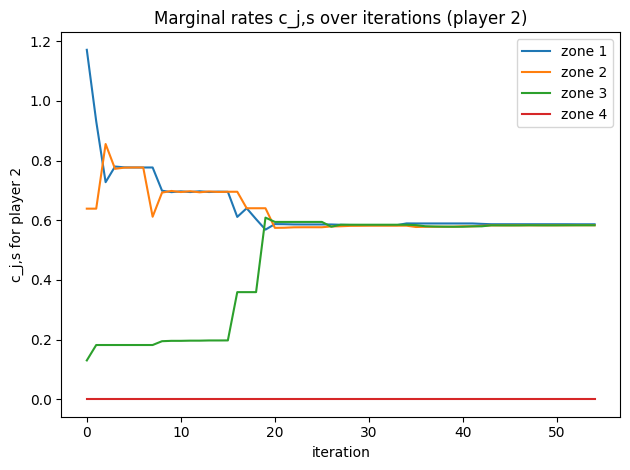

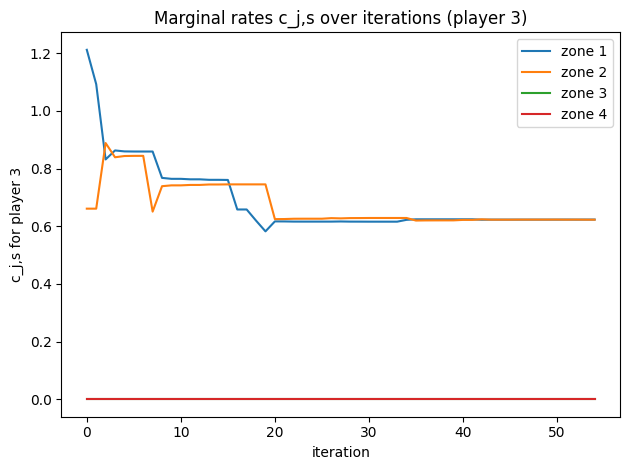

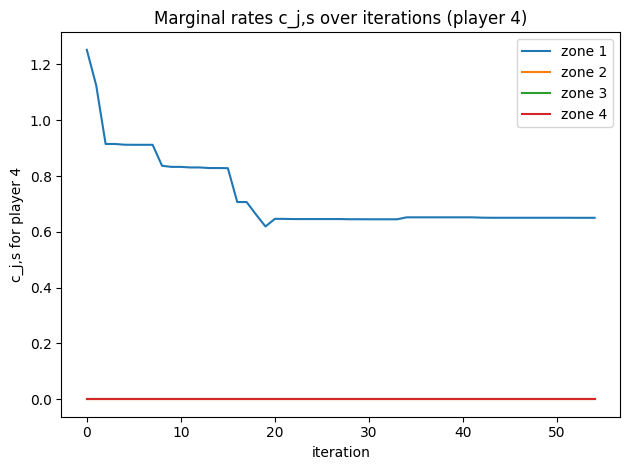

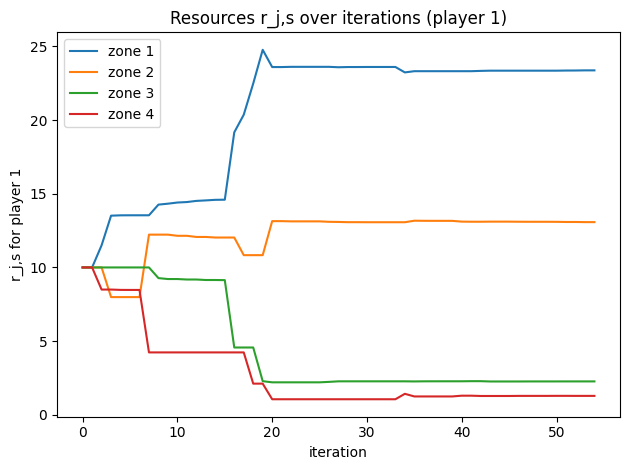

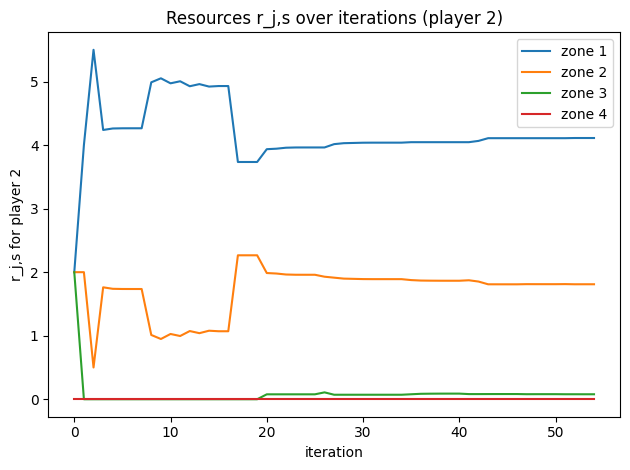

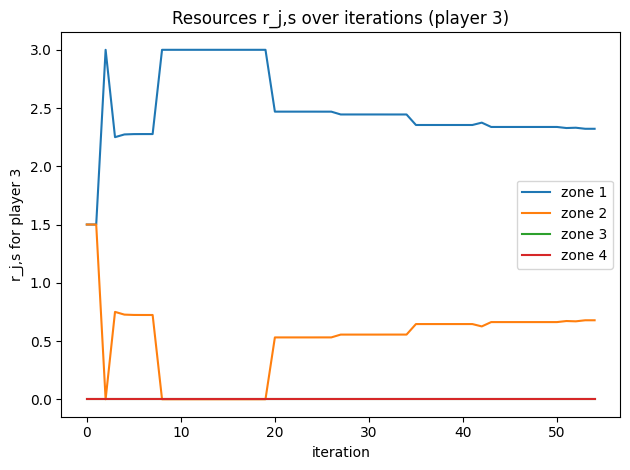

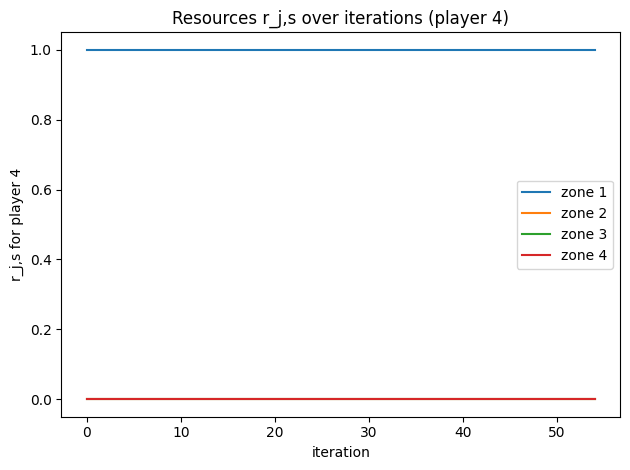

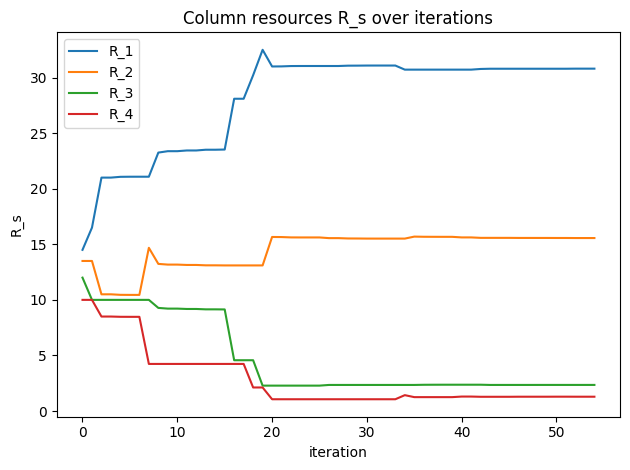

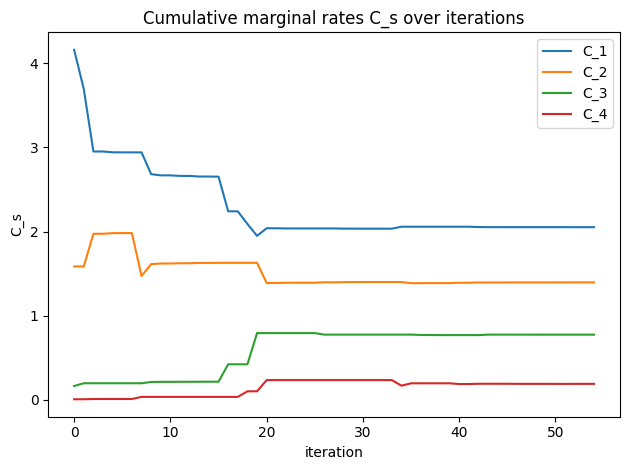

In [30]:
solver = RestrictedGMUSolver(spec, enable_logging=True)
solver.initialize_r_zone_uniform()
marg_final = solver.run(tol_disruption=1e-6, max_outer_iter=100)

# Static plots
plot_c_history(solver, players=[0, 1, 2, 3], zones=[0, 1, 2, 3])
plot_r_history(solver, players=[0, 1, 2, 3], zones=[0, 1, 2, 3])
plot_R_C_history(solver)
plt.savefig("my_plot_output.png")

# Animation (in Jupyter)
# from IPython.display import HTML
# ani = animate_c_heatmap(solver, interval=400)
# HTML(ani.to_jshtml())

#### Visualizing global Nash search 1

In [31]:
from dataclasses import dataclass
from typing import List

@dataclass
class GlobalFrame:
    step_idx: int          # global step index (k-move index)
    k: List[int]           # current cutoff vector
    zones: List["ZoneSpec"]
    entry: "HistoryEntry"  # one snapshot from solver.history

In [32]:
import numpy as np

def reconstruct_X_and_cproj_from_entry(a, zones, entry):
    """
    From a single HistoryEntry, reconstruct:

      - X[j, i]: resource of player j in project i
      - c_proj[j, i]: marginal rate c_{j,i}, by assigning the zone-level c_{j,s}
        to all projects in that zone where player j is active.
    """
    a = np.asarray(a, dtype=float)
    n = len(a)
    r_zone = entry.r_zone      # shape (m, S)
    C_cols = entry.C_cols      # shape (S,)
    c_rows = entry.c_rows      # shape (m, S)

    m, S = r_zone.shape
    X = np.zeros((m, n), dtype=float)
    c_proj = np.zeros((m, n), dtype=float)

    for s, zone in enumerate(zones):
        proj_idx = list(zone.project_indices)
        if not proj_idx:
            continue

        # Build r_zone_s dict: player j -> resource in this zone
        r_zone_s = {j: r_zone[j, s] for j in zone.active_players}
        C_s = float(C_cols[s])

        # Use your existing allocator
        x_zone = allocate_within_zone(
            a=a,
            zone=zone,
            r_zone_s=r_zone_s,
            C_s=C_s,
            c_per_player_s=None,
            clamp_negative=True,
        )

        # Fill X for each active player j in this zone
        for j in zone.active_players:
            x_j_local = x_zone[j]      # length = len(proj_idx)
            for local_idx, i in enumerate(proj_idx):
                X[j, i] += x_j_local[local_idx]

        # Fill c_proj: c_{j,s} assigned to all projects in this zone
        for j in zone.active_players:
            c_js = c_rows[j, s]
            for i in proj_idx:
                c_proj[j, i] = c_js

    return X, c_proj

In [33]:
def compute_bc_visual_data(a, zones, entry, X, active_tol=1e-10):
    a = np.asarray(a, dtype=float)
    n = len(a)
    c_rows = entry.c_rows
    m, _ = c_rows.shape

    proj_to_zone = [-1] * n
    for s, zone in enumerate(zones):
        for i in zone.project_indices:
            proj_to_zone[i] = s

    i_boundary = np.full(m, -1, dtype=int)
    deriv_boundary = np.zeros(m, dtype=float)
    c_last = np.zeros(m, dtype=float)

    for j in range(m):
        active_proj = [i for i in range(n) if X[j, i] > active_tol]
        if not active_proj:
            continue

        k_j = max(active_proj)
        if k_j >= n - 1:
            continue

        boundary_i = k_j + 1
        s_last = proj_to_zone[k_j]
        if s_last < 0:
            continue

        c_j_last = c_rows[j, s_last]
        c_last[j] = c_j_last

        L_minus_j = np.sum(X[:, boundary_i]) - X[j, boundary_i]
        deriv = a[boundary_i] / (1.0 + L_minus_j)

        i_boundary[j] = boundary_i
        deriv_boundary[j] = deriv

    return {
        "i_boundary": i_boundary,
        "deriv_boundary": deriv_boundary,
        "c_last": c_last,
    }

In [34]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
from matplotlib.animation import FuncAnimation

def _plot_3d_bars(ax, Z, zmax, title, zlabel="level"):
    """
    Draw a 3D bar plot for a matrix Z[j,i].
    j = player index (y-axis), i = project index (x-axis).
    """
    ax.cla()
    m, n = Z.shape

    # coordinates
    _x = np.arange(n)
    _y = np.arange(m)
    xx, yy = np.meshgrid(_x, _y)

    x = xx.ravel()
    y = yy.ravel()
    z = np.zeros_like(x, dtype=float)
    dx = 0.8 * np.ones_like(x, dtype=float)
    dy = 0.8 * np.ones_like(x, dtype=float)
    dz = Z.ravel()

    ax.bar3d(x, y, z, dx, dy, dz, shade=True)

    ax.set_xlim(0, n)
    ax.set_ylim(0, m)
    ax.set_zlim(0, zmax if zmax > 0 else 1.0)

    ax.set_xlabel("project i")
    ax.set_ylabel("player j")
    ax.set_zlabel(zlabel)
    ax.set_title(title)

def _plot_3d_bars_with_bc(
    ax,
    Z,
    zmax,
    title,
    zlabel="level",
    bc_vis=None,
    flip_players=False,
    bc_cap=None,
    bc_alpha=0.4,        # <--- NEW: transparency for BC bars
    bc_shrink=0.3,       # <--- NEW: 0.0 = same width, 0.3 = 30% thinner
    plot_boundary_conditions=True
):
    ax.cla()
    m, n = Z.shape

    if flip_players:
        Z_plot = Z[::-1, :]
    else:
        Z_plot = Z

    _x = np.arange(n)
    _y = np.arange(m)
    xx, yy = np.meshgrid(_x, _y)

    x = xx.ravel().astype(float)
    y = yy.ravel().astype(float)
    z0 = np.zeros_like(x, dtype=float)
    dx = 0.8 * np.ones_like(x, dtype=float)
    dy = 0.8 * np.ones_like(x, dtype=float)
    dz = Z_plot.ravel().copy()

    N = len(dz)
    base_color = plt.get_cmap("Blues")(0.6)
    colors = np.tile(base_color, (N, 1))

    if bc_vis is not None and plot_boundary_conditions:
        i_boundary = bc_vis["i_boundary"]
        deriv_boundary = bc_vis["deriv_boundary"]

        for j in range(m):
            i_b = int(i_boundary[j])
            if i_b < 0:
                continue

            j_plot = m - 1 - j if flip_players else j
            idx = j_plot * n + i_b

            # height (clipped)
            val = deriv_boundary[j]
            if bc_cap is not None:
                val = min(val, bc_cap)
            dz[idx] = val

            # color with transparency
            colors[idx] = (1.0, 0.0, 0.0, bc_alpha)  # RGBA

            # optional shrink in width so you can see blue edges around them
            if bc_shrink > 0.0:
                shrink = 1.0 - bc_shrink  # e.g. 0.7 if bc_shrink=0.3
                # center a smaller bar in the same cell
                dx[idx] *= shrink
                dy[idx] *= shrink
                x[idx] += (0.8 - dx[idx]) / 2.0
                y[idx] += (0.8 - dy[idx]) / 2.0

    ax.bar3d(x, y, z0, dx, dy, dz, color=colors, shade=True)

    ax.set_xlim(0, n)
    ax.set_ylim(0, m)
    ax.set_zlim(0, zmax if zmax > 0 else 1.0)

    ax.set_xlabel("project i")
    ax.set_ylabel("player j")
    ax.set_zlabel(zlabel)
    ax.set_title(title)

def animate_global_frames_3d(
    a,
    global_frames,
    interval=400,
    save_path=None,
    vmax_resources=None,
    vmax_c=None,
):
    """
    Core 3D animation function.

    Parameters
    ----------
    a : array_like, shape (n,)
        Project parameters.
    global_frames : list[GlobalFrame]
        Each frame has .k, .zones, .entry; we reconstruct X and c[j,i].
        - If you only put one entry per configuration, you get "between configs" dynamics.
        - If you put all solver.history entries, you get full A/B dynamics.
    interval : int
        Milliseconds between frames.
    save_path : str or None
        If set, save to this path (e.g. 'ne_global.mp4' or 'ne_global.gif').
    vmax_resources, vmax_c : float or None
        z-limits for resources and marginals; if None, computed from all frames.

    Returns
    -------
    anim : FuncAnimation
    """

    if not global_frames:
        raise ValueError("global_frames is empty.")
        
    a = np.asarray(a, dtype=float)
    n = len(a)

    # ---------- precompute X, c_proj, BC data for each frame ----------
    X_list = []
    C_list = []
    BC_list = []

    for gf in global_frames:
        # 1) per-frame X and per-project c
        X, c_proj = reconstruct_X_and_cproj_from_entry(a, gf.zones, gf.entry)
        X_list.append(X)
        C_list.append(c_proj)

        # 2) per-frame boundary-derivative data
        bc_vis = compute_bc_visual_data(a, gf.zones, gf.entry, X)
        BC_list.append(bc_vis)

    # collect all c-values and BC derivatives across frames
    all_c_vals = np.concatenate([C.ravel() for C in C_list])
    all_bc_vals = np.concatenate([bc["deriv_boundary"] for bc in BC_list
                                  if bc["deriv_boundary"].size > 0])
    
    finite_bc = all_bc_vals[all_bc_vals > 0]
    
    if vmax_c is None:
        # e.g. cap at 99th percentile of c's and 95th of BCs
        c_cap  = np.percentile(all_c_vals, 99) if all_c_vals.size else 1.0
        bc_cap = np.percentile(finite_bc, 85) if finite_bc.size else c_cap
        vmax_c = max(c_cap, bc_cap)
    else:
        bc_cap = vmax_c  # if user forces vmax_c, use same for BC clipping

    m = X_list[0].shape[0]

    if vmax_resources is None:
        vmax_resources = max(float(np.max(X)) for X in X_list) or 1.0

    # ---------- set up figure ----------
    fig = plt.figure(figsize=(10, 5))
    ax_res = fig.add_subplot(1, 2, 1, projection="3d")
    ax_c   = fig.add_subplot(1, 2, 2, projection="3d")

    # ---------- initial frame ----------
    X0      = X_list[0]
    C0      = C_list[0]
    bc0     = BC_list[0]
    gf0     = global_frames[0]

    _plot_3d_bars(ax_res, X0, vmax_resources,
                  title=f"Resources X[j,i] – step {gf0.step_idx}, k={gf0.k}",
                  zlabel="resource")

    _plot_3d_bars_with_bc(
        ax_c,
        C0,
        vmax_c,
        title=f"Marginals c[j,i] – step {gf0.step_idx}, k={gf0.k}",
        zlabel="c",
        bc_vis=bc0,
        flip_players=False,
        bc_cap=bc_cap,
        plot_boundary_conditions=True
    )

    # ---------- update function ----------
    def update(frame_idx):
        X      = X_list[frame_idx]
        Cproj  = C_list[frame_idx]
        bc_vis = BC_list[frame_idx]
        gf     = global_frames[frame_idx]
    
        _plot_3d_bars(
            ax_res,
            X,
            vmax_resources,
            title=f"Resources X[j,i] – step {gf.step_idx}, k={gf.k}",
            zlabel="resource",
        )
    
        _plot_3d_bars_with_bc(
            ax_c,
            Cproj,
            vmax_c,
            title=f"Marginals c[j,i] – step {gf.step_idx}, k={gf.k}",
            zlabel="c",
            bc_vis=bc_vis,
            bc_cap=bc_cap,
            flip_players=False,   # or True in your setup
        )
    
        return ax_res, ax_c

    anim = FuncAnimation(
        fig,
        update,
        frames=len(global_frames),
        interval=interval,
        blit=False,
    )

    if save_path:
        anim.save(save_path, fps=1000 // interval)
    return anim


def compress_global_frames(
    frames,
    tol_r_rel: float = 1e-2,
    tol_c_rel: float = 1e-2,
):
    """
    Compress a list of GlobalFrame objects by removing frames where
    the change in r_zone and c_rows is visually negligible.

    - Always keeps the first frame overall.
    - Always keeps the first frame of a new k-step (step_idx changes).
    - Within a fixed step_idx, keeps a frame only if
        ||Δ r_zone|| / ||r_zone_prev|| > tol_r_rel  or
        ||Δ c_rows|| / ||c_rows_prev|| > tol_c_rel.

    Parameters
    ----------
    frames : list[GlobalFrame]
    tol_r_rel : float
        Relative threshold for changes in r_zone.
    tol_c_rel : float
        Relative threshold for changes in c_rows.

    Returns
    -------
    compressed : list[GlobalFrame]
    """
    if not frames:
        return []

    compressed = [frames[0]]
    prev = frames[0]

    for f in frames[1:]:
        # If we changed k / step_idx, always keep first frame of new config
        if (f.step_idx != prev.step_idx) or (f.k != prev.k):
            compressed.append(f)
            prev = f
            continue

        r_prev = prev.entry.r_zone
        r_curr = f.entry.r_zone
        c_prev = prev.entry.c_rows
        c_curr = f.entry.c_rows

        # Frobenius norms
        dr = np.linalg.norm(r_curr - r_prev)
        dc = np.linalg.norm(c_curr - c_prev)
        nr = np.linalg.norm(r_prev) + 1e-12
        nc = np.linalg.norm(c_prev) + 1e-12

        rel_dr = dr / nr
        rel_dc = dc / nc

        if (rel_dr > tol_r_rel) or (rel_dc > tol_c_rel):
            compressed.append(f)
            prev = f
        else:
            # change is tiny -> skip this frame
            pass

    return compressed

In [35]:
a = np.array([100, 80, 50, 10, 5, 3, 0.1], dtype=float)
r_total = np.array([10, 8, 7, 5, 1], dtype=float)

a = np.array([12, 11, 3, 2, 1, 0.1], dtype=float)
r_total = np.array([100, 8, 7, 1], dtype=float)

# a = np.array([15, 7, 5, 4, 3, 2, 1], dtype=float)
# r_total = np.array([40.0, 6.0, 3.0, 1.0], dtype=float)

In [36]:
best_solver, best_marg, best_k, best_bc, best_disr, X_best, frames_between = \
    find_global_NE_by_k_search(
        a,
        r_total,
        record_mode="between",
        verbose=True
    )


=== k-step 1/24 ===
Current k: [1, 1, 1, 1]
  BC penalty = 1.098510e+01, disruption = 0.000000e+00
  BC by player = [10.98509752 10.90444883 10.90357221 10.89831251]
  Rates matrix = [[0.01490248]
 [0.09555117]
 [0.09642779]
 [0.10168749]]
  Investments matrix = [[100.   0.   0.   0.   0.   0.]
 [  8.   0.   0.   0.   0.   0.]
 [  7.   0.   0.   0.   0.   0.]
 [  1.   0.   0.   0.   0.   0.]]
  Expanding player j=0 from k_j=1 to k_j=2

=== k-step 2/24 ===
Current k: [2, 1, 1, 1]
  BC penalty = 2.977754e+00, disruption = 1.000001e-06
  BC by player = [2.97775402 0.37983672 0.37852819 0.37067702]
  Rates matrix = [[0.02224498 0.02224598]
 [0.11484075 0.        ]
 [0.11614928 0.        ]
 [0.12400045 0.        ]]
  Investments matrix = [[78.76328903 21.23671097  0.          0.          0.          0.        ]
 [ 8.          0.          0.          0.          0.          0.        ]
 [ 7.          0.          0.          0.          0.          0.        ]
 [ 1.          0.          0.  

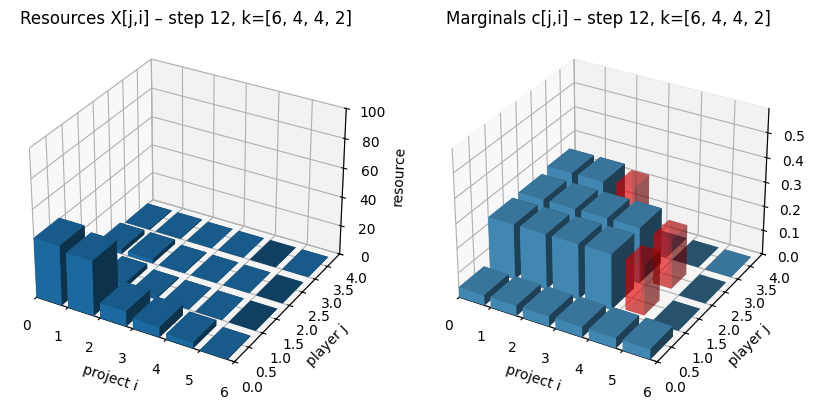

In [37]:
anim_between = animate_global_frames_3d(
    a=a,
    global_frames=frames_between,
    interval=500,
    save_path="ne_between_configs.mp4",
)
plt.show()

In [38]:
best_solver, best_marg, best_k, best_bc, best_disr, X_best, frames_full = \
    find_global_NE_by_k_search(
        a,
        r_total,
        record_mode="full",
    )


=== k-step 1/24 ===
Current k: [1, 1, 1, 1]
  BC penalty = 1.098510e+01, disruption = 0.000000e+00
  BC by player = [10.98509752 10.90444883 10.90357221 10.89831251]
  Rates matrix = [[0.01490248]
 [0.09555117]
 [0.09642779]
 [0.10168749]]
  Investments matrix = [[100.   0.   0.   0.   0.   0.]
 [  8.   0.   0.   0.   0.   0.]
 [  7.   0.   0.   0.   0.   0.]
 [  1.   0.   0.   0.   0.   0.]]
  Expanding player j=0 from k_j=1 to k_j=2

=== k-step 2/24 ===
Current k: [2, 1, 1, 1]
  BC penalty = 2.977754e+00, disruption = 1.000001e-06
  BC by player = [2.97775402 0.37983672 0.37852819 0.37067702]
  Rates matrix = [[0.02224498 0.02224598]
 [0.11484075 0.        ]
 [0.11614928 0.        ]
 [0.12400045 0.        ]]
  Investments matrix = [[78.76328903 21.23671097  0.          0.          0.          0.        ]
 [ 8.          0.          0.          0.          0.          0.        ]
 [ 7.          0.          0.          0.          0.          0.        ]
 [ 1.          0.          0.  

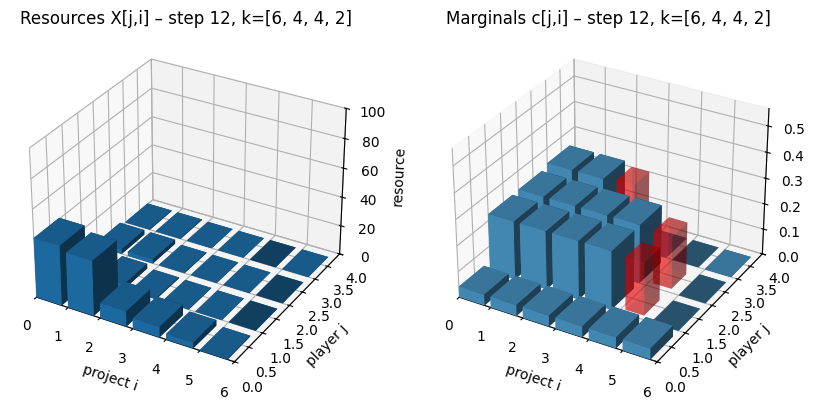

In [39]:
anim_full = animate_global_frames_3d(
    a=a,
    global_frames=frames_full,
    interval=100,
    save_path="ne_full_dynamics.mp4",
)
plt.show()

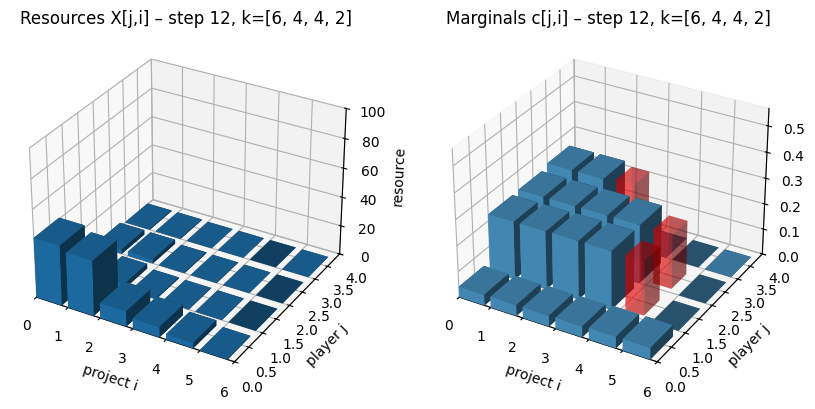

In [40]:
frames_full_compressed = compress_global_frames(
    frames_full,
    tol_r_rel=1e-2,
    tol_c_rel=1e-2,
)

anim_full = animate_global_frames_3d(
    a=a,
    global_frames=frames_full_compressed,
    interval=200,
    save_path="ne_full_compressed_dynamics.mp4",
)
plt.show()

### Updated algorithm

In [38]:
def _active_in_project(X: np.ndarray, j: int, proj_i: int, eps_mass: float) -> bool:
    """True iff player j invests positive mass in project proj_i (0-based)."""
    if proj_i < 0 or proj_i >= X.shape[1]:
        return False
    return float(X[j, proj_i]) > eps_mass


def _eligible_by_prev_project_activity(
    X: np.ndarray, j: int, target_K: int, eps_mass: float
) -> bool:
    """
    Monotonicity gate: to allow player j into project target_K (1-based),
    require that they were active in the previous project target_K-1 (1-based).

    For target_K=1, always eligible.
    """
    if target_K <= 1:
        return True
    prev_proj_i = (target_K - 1) - 1  # (target_K-1) in 1-based -> 0-based
    return _active_in_project(X, j, prev_proj_i, eps_mass)

def bc_wants_expand(bc_by_player: np.ndarray, j: int, tol: float) -> bool:
    # Interprets bc_by_player[j] as "how badly player j violates boundary conditions"
    return float(bc_by_player[j]) > tol
    

@dataclass
class OuterSnapshot:
    step: int
    phase: str                  # "solve", "expand_existing", "expand_new", "refuse_existing", "refuse_new", ...
    player: Optional[int]
    target_K: Optional[int]      # 1-based
    k: List[int]
    stopped: List[bool]
    bc_penalty: float
    bc_by_player: np.ndarray
    d_rows: float
    invested_target: Optional[float] = None
    note: str = ""
    # Optional payloads for visualization/debugging:
    X: Optional[np.ndarray] = None
    solver_last_entry: Any = None
    frame_id: int = 0   # NEW

In [39]:
def _solve_restricted(
    a: np.ndarray,
    r_players: np.ndarray,
    k: List[int],
    *,
    max_iter_inner: int,
    tol_row_inner: float,
    enable_logging: bool,
) -> Tuple[Any, Any, np.ndarray, float, float, np.ndarray]:
    """
    Calls your existing restricted solver wrapper.

    Must return:
        solver, marg, X, d_rows, bc_penalty, bc_by_player
    """
    out = run_mug_restricted_for_k(
        a,
        r_players,
        k,
        max_iter=max_iter_inner,
        tol_row=tol_row_inner,
        enable_logging=enable_logging,
    )
    if len(out) != 6:
        raise RuntimeError(
            "run_mug_restricted_for_k must return (solver, marg, X, d_rows, bc_penalty, bc_by_player)."
        )
    solver, marg, X, d_rows, bc_penalty, bc_by_player = out
    return solver, marg, X, float(d_rows), float(bc_penalty), np.asarray(bc_by_player, dtype=float)

In [40]:
def _proj_to_zone_map(solver) -> list[int]:
    """Map project index i -> zone s (0..S-1) based on solver.zones."""
    # assumes solver.zones entries have .project_indices
    n = max(max(z.project_indices) for z in solver.zones) + 1 if solver.zones else 0
    proj_to_zone = [-1] * n
    for s, zone in enumerate(solver.zones):
        for i in zone.project_indices:
            if i >= 0 and i < n:
                proj_to_zone[i] = s
    return proj_to_zone


def bc_details_df(
    solver,
    marg,
    a: np.ndarray,
    X: np.ndarray,
    r_players: np.ndarray,
    *,
    active_tol: float = 1e-10,
    k_perm: list[int] | None = None,
    stopped: list[bool] | None = None,
    cap: list[int] | None = None,
) -> pd.DataFrame:
    """
    Replicates the exact BC logic in compute_true_bc_penalty, but returns per-player ingredients.

    Columns include:
      - last_active project k_j (1-based)
      - boundary project k_j+1 (1-based)
      - s_last and c_j_last (zone and marginal)
      - L_minus_j and deriv_boundary
      - violation
    """
    a = np.asarray(a, dtype=float)
    X = np.asarray(X, dtype=float)
    r_players = np.asarray(r_players, dtype=float).reshape(-1)

    m, n = X.shape
    c_rows = marg.c_rows
    proj_to_zone = _proj_to_zone_map(solver)
    # If map shorter than n, extend with -1
    if len(proj_to_zone) < n:
        proj_to_zone = proj_to_zone + [-1] * (n - len(proj_to_zone))

    k_act = k_from_X(X, eps=active_tol)

    rows = []
    for j in range(m):
        active_proj = np.where(X[j] > active_tol)[0]
        if active_proj.size == 0:
            k_j = None
            boundary_i = None
            s_last = None
            c_j_last = None
            L_minus_j = None
            deriv_boundary = None
            viol = 0.0
        else:
            k_j = int(active_proj.max())  # 0-based
            boundary_i = k_j + 1
            if boundary_i >= n:
                boundary_i = None
                s_last = None
                c_j_last = None
                L_minus_j = None
                deriv_boundary = None
                viol = 0.0
            else:
                s_last = proj_to_zone[k_j]
                c_j_last = float(c_rows[j, s_last]) if (s_last is not None and s_last >= 0) else np.nan
                L_minus_j = float(np.sum(X[:, boundary_i]) - X[j, boundary_i])
                deriv_boundary = float(a[boundary_i] / (1.0 + L_minus_j))
                viol = float(max(0.0, deriv_boundary - c_j_last))

        rows.append(
            dict(
                j=j,
                r=float(r_players[j]),
                k_perm=None if k_perm is None else int(k_perm[j]),
                k_active=int(k_act[j]),
                stopped=None if stopped is None else bool(stopped[j]),
                cap=None if cap is None else int(cap[j]),
                last_active_1b=None if k_j is None else int(k_j + 1),
                boundary_1b=None if boundary_i is None else int(boundary_i + 1),
                s_last=s_last,
                c_j_last=c_j_last,
                L_minus_j=L_minus_j,
                deriv_boundary=deriv_boundary,
                violation=viol,
            )
        )

    df = pd.DataFrame(rows)

    # Sort by player index by default; you can reorder later
    return df


def print_step_debug(
    *,
    title: str,
    step: int,
    k_perm: list[int],
    stopped: list[bool],
    cap: list[int],
    bc_penalty: float,
    bc_by_player: np.ndarray,
    d_rows: float,
    solver,
    marg,
    a: np.ndarray,
    X: np.ndarray,
    r_players: np.ndarray,
    active_tol: float = 1e-10,
    show_df: bool = True,
) -> None:
    print(f"\n=== {title} | step={step} ===")
    print(f"k_perm={k_perm} | k_active={k_from_X(X, eps=active_tol)}")
    print(f"stopped={stopped} | cap={cap}")
    print(f"bc_penalty={bc_penalty:.6e} | bc_by_player={np.asarray(bc_by_player, float)} | d_rows={d_rows:.6e}")

    if show_df:
        df = bc_details_df(
            solver, marg, a, X, r_players,
            active_tol=active_tol,
            k_perm=k_perm,
            stopped=stopped,
            cap=cap,
        )
        # nicer formatting for notebook print
        with pd.option_context("display.max_rows", 200, "display.max_columns", 200, "display.width", 200):
            print(df)

In [41]:
# ---------- Helpers: active cutoff from support ----------
def k_from_X(X: np.ndarray, eps: float = 1e-10) -> List[int]:
    """Active cutoff (1-based): last i with X[j,i]>eps. Returns at least 1."""
    X = np.asarray(X, dtype=float)
    m, n = X.shape
    out: List[int] = []
    for j in range(m):
        pos = np.where(X[j] > eps)[0]
        out.append(int(pos.max() + 1) if pos.size else 1)
    return out


# ---------- Optional history record ----------
@dataclass
class OuterSnapshot:
    step: int
    phase: str
    player: Optional[int]
    target_K: Optional[int]
    k: List[int]
    stopped: List[bool]
    cap: List[int]
    bc_penalty: float
    bc_by_player: np.ndarray
    d_rows: float
    note: str = ""
    X: Optional[np.ndarray] = None
    
    
def find_global_NE_monotone_projects(
    a: np.ndarray,
    r_players: np.ndarray,
    *,
    max_iter_inner: int = 500,
    tol_row_inner: float = 1e-6,
    bc_tol: float = 1e-8,          # global stop
    expand_tol: float = 1e-6,      # only expand if player violation exceeds this
    stop_tol: Optional[float] = None,  # stop (refuse) if violation <= stop_tol; default expand_tol/2
    active_tol: float = 1e-10,     # support threshold for defining "active"
    max_outer_steps: Optional[int] = 50_000,
    max_tighten_iters: int = 10,   # support-tighten resolve iterations
    enable_logging: bool = False,
    verbose: bool = True,
    store_X_in_history: bool = True,
) -> Tuple[Any, Any, List[int], float, float, np.ndarray, List[OuterSnapshot]]:
    """
    Support-consistent monotone outer algorithm.

    Key invariant enforced:
      After every solve, we tighten k to the ACTIVE support k_active(X) and re-solve until stable.
      Therefore, if k[j]=K, then player j invests in project K (up to active_tol), so zone math is valid.

    Returns:
      solver, marg, k_active(final), bc_penalty, d_rows, X, history
    """
    a = np.asarray(a, dtype=float)
    r_players = np.asarray(r_players, dtype=float).reshape(-1)
    m = int(r_players.shape[0])
    n = int(a.shape[0])

    if stop_tol is None:
        stop_tol = 0.5 * expand_tol

    # high resources first
    order = list(np.argsort(-r_players))
    rank = {j: i for i, j in enumerate(order)}

    # State
    k: List[int] = [1] * m                 # "permission" k, but we will always tighten it to support
    stopped: List[bool] = [False] * m      # never attempt again
    cap: List[int] = [n] * m               # hard max project ever reachable (1-based)

    history: List[OuterSnapshot] = []

    def _record(step: int, phase: str, player: Optional[int], target_K: Optional[int],
                solver: Any, marg: Any, X: np.ndarray, d_rows: float,
                bc_penalty: float, bc_by_player: np.ndarray, note: str = "") -> None:
        history.append(
            OuterSnapshot(
                step=step,
                phase=phase,
                player=player,
                target_K=target_K,
                k=list(k),
                stopped=list(stopped),
                cap=list(cap),
                bc_penalty=float(bc_penalty),
                bc_by_player=np.asarray(bc_by_player, dtype=float).copy(),
                d_rows=float(d_rows),
                note=note,
                X=(X.copy() if store_X_in_history else None),
            )
        )

    # ---- Monotone “refusal cap”: if j refuses project K, all lower-ranked capped at K-1 ----
    def _apply_refusal_cap(j_refuse: int, refused_K: int) -> None:
        cap_value = refused_K - 1
        r_ref = rank[j_refuse]
        for jj in order:
            if rank[jj] > r_ref:
                cap[jj] = min(cap[jj], cap_value)
                if k[jj] > cap[jj]:
                    k[jj] = cap[jj]

    # ---- Solve + support-tighten until k == k_active(X) (up to active_tol) ----
    def _solve_and_tighten(step: int, phase: str, player: Optional[int], target_K: Optional[int], note: str = ""):
        nonlocal solver, marg, X, d_rows, bc_penalty, bc_by_player, k
    
        # ---- First solve: record under the requested phase ----
        solver, marg, X, d_rows, bc_penalty, bc_by_player = _solve_restricted(
            a, r_players, k,
            max_iter_inner=max_iter_inner,
            tol_row_inner=tol_row_inner,
            enable_logging=enable_logging,
        )
        _record(step, phase, player, target_K, solver, marg, X, d_rows, bc_penalty, bc_by_player,
                note=note + " | solve")
    
        # ---- Tighten loop: record under "tighten" so animation can ignore it ----
        for it in range(max_tighten_iters):
            k_act = k_from_X(X, eps=active_tol)
            k_tight = [min(k[jj], k_act[jj]) for jj in range(m)]
            if k_tight == k:
                break
    
            k = k_tight
            solver, marg, X, d_rows, bc_penalty, bc_by_player = _solve_restricted(
                a, r_players, k,
                max_iter_inner=max_iter_inner,
                tol_row_inner=tol_row_inner,
                enable_logging=enable_logging,
            )
            _record(step, "tighten", player, target_K, solver, marg, X, d_rows, bc_penalty, bc_by_player,
                    note=f"tighten it={it+1} | k_active={k_act}")

    # ---- Attempt to expand player j to target_K (1-based). Accept only if it sticks in support. ----
    def _attempt_expand(step: int, phase: str, j: int, target_K: int) -> bool:
        nonlocal k
        old_k = k[j]
        k_trial = list(k)
        k_trial[j] = min(target_K, cap[j])
        k = k_trial

        _solve_and_tighten(step, phase, j, target_K, note="trial expand + support-tighten")

        # After tightening, k equals active support. So "sticks" iff k[j] == target_K.
        if k[j] == target_K:
            return True

        # Otherwise, treat as a refusal to enter target_K: revert in the sense of "no support expansion"
        # (k is already tightened; we just interpret this as refusal.)
        return False

    # ========== INITIAL SOLVE ==========
    solver = marg = None
    X = None
    d_rows = bc_penalty = 0.0
    bc_by_player = np.zeros(m, dtype=float)

    _solve_and_tighten(0, "solve_init", None, None)
    if verbose:
        print(f"[init] k_active={k}  bc={bc_penalty:.3e}  d_rows={d_rows:.3e}")

    # ========== OUTER LOOP ==========
    step = 0
    while bc_penalty > bc_tol:
        step += 1
        if max_outer_steps is not None and step > max_outer_steps:
            raise RuntimeError(f"Exceeded max_outer_steps={max_outer_steps} with bc_penalty={bc_penalty}.")

        K = max(k)  # current frontier in support-consistent sense

        # ------------------------------------------------------------
        # Phase A: try to expand lagging players into EXISTING frontier (step-by-step)
        # ------------------------------------------------------------
        did_anything = False

        for j in order:
            if stopped[j]:
                continue

            # lagging only
            if k[j] >= K:
                continue

            # next project they would enter
            next_K = k[j] + 1

            # cap check
            if next_K > cap[j] or next_K > K:
                continue

            # If BC says they do NOT need to enter next_K, this is a refusal event
            # that triggers "stop forever" and caps lower-ranked at next_K-1 (=k[j]).
            vj = float(bc_by_player[j])
            if vj <= stop_tol:
                stopped[j] = True
                _apply_refusal_cap(j, next_K)
                _record(step, "stop_existing_bc_satisfied", j, next_K, solver, marg, X, d_rows, bc_penalty, bc_by_player,
                        note=f"vj={vj:.3e} <= stop_tol; stop + cap lower at {next_K-1}")
                if verbose:
                    print(f"[step {step}] stop_existing j={j} refuses {next_K} (vj={vj:.2e}); cap lower at {next_K-1}")
                did_anything = True
                break  # monotone: once higher-ranked refuses, do not try lower-ranked for that project

            # Only try expansion if violation is meaningfully positive
            if vj <= expand_tol:
                continue

            # Attempt expand by one
            ok = _attempt_expand(step, "expand_existing", j, next_K)
            if ok:
                if verbose:
                    print(f"[step {step}] expand_existing j={j} -> {next_K} | bc={bc_penalty:.3e}")
                did_anything = True
                break

            # Expansion did not stick => treat as refusal
            stopped[j] = True
            _apply_refusal_cap(j, next_K)
            _record(step, "refuse_existing_no_support", j, next_K, solver, marg, X, d_rows, bc_penalty, bc_by_player,
                    note="trial expansion did not stick in support; stop + cap lower-ranked")
            if verbose:
                print(f"[step {step}] refuse_existing j={j} for {next_K} (no support); cap lower at {next_K-1}")
            did_anything = True
            break

        if did_anything:
            continue

        # ------------------------------------------------------------
        # Phase B: open NEW project (K -> K+1)
        # Only players with k[j]==K (active at frontier) may enter K+1.
        # ------------------------------------------------------------
        if K >= n:
            # cannot open beyond n; do a full-access fallback once (still support-tightened)
            if verbose:
                print(f"[step {step}] K=n={n} but bc={bc_penalty:.3e} > bc_tol; fallback full-access.")
            k = [n] * m
            _solve_and_tighten(step, "fallback_full_access", None, n, note="full access fallback")
            break

        target_K = K + 1

        # candidates: active at frontier (k[j]==K), not stopped, can reach target_K by cap
        candidates = [j for j in order if (not stopped[j]) and (cap[j] >= target_K) and (k[j] == K)]
        if not candidates:
            raise RuntimeError(f"No candidates to open new project {target_K} from frontier {K}.")

        seeded_any = False
        for j in candidates:
            vj = float(bc_by_player[j])

            # If BC says satisfied (vj small), this is a refusal to enter target_K: stop+cap lower and stop scanning.
            if vj <= stop_tol:
                stopped[j] = True
                _apply_refusal_cap(j, target_K)
                _record(step, "refuse_new_bc_satisfied", j, target_K, solver, marg, X, d_rows, bc_penalty, bc_by_player,
                        note=f"vj={vj:.3e} <= stop_tol; stop + cap lower at {target_K-1}; stop scanning")
                if verbose:
                    print(f"[step {step}] refuse_new j={j} at {target_K} (vj={vj:.2e}); cap lower at {target_K-1}")
                break

            # Only expand if violation is meaningfully positive
            if vj <= expand_tol:
                continue

            ok = _attempt_expand(step, "expand_new", j, target_K)
            if ok:
                seeded_any = True
                if verbose:
                    print(f"[step {step}] expand_new j={j} -> {target_K} | bc={bc_penalty:.3e}")
                # continue trying next players until first refusal
                continue

            # did not stick in support => refusal event; stop+cap lower and stop scanning
            stopped[j] = True
            _apply_refusal_cap(j, target_K)
            _record(step, "refuse_new_no_support", j, target_K, solver, marg, X, d_rows, bc_penalty, bc_by_player,
                    note="trial expansion to new project did not stick in support; stop+cap lower; stop scanning")
            if verbose:
                print(f"[step {step}] refuse_new j={j} at {target_K} (no support); cap lower at {target_K-1}")
            break

        if not seeded_any and bc_penalty > bc_tol:
            raise RuntimeError(
                f"Opened candidate set for new project {target_K}, but nobody entered with vj>expand_tol "
                f"while bc_penalty={bc_penalty:.3e} > bc_tol={bc_tol:.3e}. "
                f"Try lowering expand_tol/stop_tol or inspect bc_by_player semantics."
            )

    if verbose:
        print(f"[done] step={step} k_active={k} bc={bc_penalty:.3e} d_rows={d_rows:.3e}")

    return solver, marg, k, bc_penalty, d_rows, X, history

In [42]:
# Example usage:
# a = np.array([100, 80, 50, 10, 5, 3, 0.1], dtype=float)
# r_total = np.array([10, 8, 7, 5, 1], dtype=float)

a = np.array([12, 11, 3, 2, 1, 0.1], dtype=float)
r_total = np.array([100, 8, 7, 1], dtype=float)

solver_new, marg_new, k_new, bc_new, drows_new, X_new, outer_hist = find_global_NE_monotone_projects(
    a,
    r_total,               # or your r_players vector name
    max_iter_inner=500,
    tol_row_inner=1e-6,
    bc_tol=1e-6,
    eps_mass=1e-10,
    max_outer_steps=10_000,
    enable_logging=False,
    verbose=True,
    store_X_in_history=True,
)

print("Final k:", k_new)
print("Final BC penalty:", bc_new)
print("Final global disruption:", drows_new)
print("Final allocation X:\n", X_new)

TypeError: find_global_NE_monotone_projects() got an unexpected keyword argument 'eps_mass'

In [43]:
# Example usage:
# a = np.array([15, 14, 13, 12, 11], dtype=float)
# r_total = np.array([10, 9, 8, 7], dtype=float)

# a = np.array([10, 9, 8, 3, 2], dtype=float)
# r_total = np.array([15, 14, 2, 1], dtype=float)

a = np.array([12, 11, 3, 2, 1, 0.1], dtype=float)
r_total = np.array([100, 8, 7, 1], dtype=float)

# a = np.array([12, 11, 3, 2, 1, 0.1], dtype=float)
# r_total = np.array([100, 8, 7, 1], dtype=float)

solver_new, marg_new, k_new, bc_new, drows_new, X_new, outer_hist = find_global_NE_monotone_projects(
    a,
    r_total,
    max_iter_inner=500,
    tol_row_inner=1e-6,
    bc_tol=1e-6,
    expand_tol=1e-6,      # you can tune
    stop_tol=5e-7,        # or leave None
    active_tol=1e-10,     # <-- replaces eps_mass
    max_outer_steps=10_000,
    max_tighten_iters=10,
    enable_logging=False,
    verbose=True,
    store_X_in_history=True,
)

print("Final k:", k_new)
print("Final BC penalty:", bc_new)
print("Final global disruption:", drows_new)
print("Final allocation X:\n", X_new)

[init] k_active=[1, 1, 1, 1]  bc=1.099e+01  d_rows=0.000e+00
[step 1] expand_new j=0 -> 2 | bc=2.978e+00
[step 1] expand_new j=1 -> 2 | bc=2.971e+00
[step 1] expand_new j=2 -> 2 | bc=2.970e+00
[step 1] expand_new j=3 -> 2 | bc=2.970e+00
[step 2] expand_new j=0 -> 3 | bc=1.966e+00
[step 2] expand_new j=1 -> 3 | bc=1.965e+00
[step 2] expand_new j=2 -> 3 | bc=1.951e+00
[step 2] refuse_new j=3 at 3 (no support); cap lower at 2
[step 3] expand_new j=0 -> 4 | bc=9.615e-01
[step 3] refuse_new j=1 at 4 (no support); cap lower at 3
[step 4] expand_existing j=2 -> 3 | bc=9.615e-01
[step 5] expand_new j=0 -> 5 | bc=6.495e-02
[step 6] expand_new j=0 -> 6 | bc=1.887e-02
[step 7] K=n=6 but bc=1.887e-02 > bc_tol; fallback full-access.
[done] step=7 k_active=[6, 4, 4, 2] bc=0.000e+00 d_rows=5.459e-04
Final k: [6, 4, 4, 2]
Final BC penalty: 0.0
Final global disruption: 0.0005459279458015498
Final allocation X:
 [[40.78663837 37.40571497 10.36810691  7.0098973   3.88490109  0.54474136]
 [ 3.67748949  3.

In [44]:
@dataclass
class AlgoResult:
    name: str
    k: Optional[np.ndarray]
    X: np.ndarray
    bc_penalty: Optional[float]
    d_rows: Optional[float]
    solver: Any = None
    marg: Any = None
    history: Any = None
    raw: Any = None


def _as_1d_int(x: Any) -> Optional[np.ndarray]:
    if x is None:
        return None
    arr = np.asarray(x)
    if arr.size == 0:
        return arr.astype(int)
    return arr.astype(int).reshape(-1)


def _as_2d_float(X: Any) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape={X.shape}.")
    return X


def normalize_algo_output(
    name: str,
    out: Any,
    *,
    # If your old algorithm doesn't return bc_penalty / d_rows, we can compute them externally later.
    expect_X_key: str = "X",
) -> AlgoResult:
    """
    Make algorithm outputs comparable.

    Supported output styles:
      - dict with keys: X, k, bc_penalty, d_rows, solver, marg, history
      - tuple/list with common patterns:
          new: (solver, marg, k, bc_penalty, d_rows, X, history)
          your old might be: (..., k, ..., X, ...) or (..., X, ...)
    """
    # 1) Dict-style
    if isinstance(out, dict):
        X = _as_2d_float(out.get(expect_X_key))
        k = _as_1d_int(out.get("k", None))
        bc_penalty = out.get("bc_penalty", None)
        d_rows = out.get("d_rows", None)
        return AlgoResult(
            name=name,
            k=k,
            X=X,
            bc_penalty=None if bc_penalty is None else float(bc_penalty),
            d_rows=None if d_rows is None else float(d_rows),
            solver=out.get("solver", None),
            marg=out.get("marg", None),
            history=out.get("history", None),
            raw=out,
        )

    # 2) Tuple/list-style (best-effort extraction)
    if isinstance(out, (tuple, list)):
        L = len(out)

        # New algorithm shape: (solver, marg, k, bc_penalty, d_rows, X, history)
        if L == 7:
            solver, marg, k, bc_penalty, d_rows, X, history = out
            return AlgoResult(
                name=name,
                k=_as_1d_int(k),
                X=_as_2d_float(X),
                bc_penalty=float(bc_penalty),
                d_rows=float(d_rows),
                solver=solver,
                marg=marg,
                history=history,
                raw=out,
            )

        # If X is last
        if L >= 1 and np.asarray(out[-1]).ndim == 2:
            X = out[-1]
            return AlgoResult(name=name, k=None, X=_as_2d_float(X), bc_penalty=None, d_rows=None, raw=out)

        # If X is second-to-last
        if L >= 2 and np.asarray(out[-2]).ndim == 2:
            X = out[-2]
            return AlgoResult(name=name, k=None, X=_as_2d_float(X), bc_penalty=None, d_rows=None, raw=out)

        raise ValueError(
            f"Don't know how to parse output tuple of length {L} for {name}. "
            f"Return a dict or (solver, marg, k, bc_penalty, d_rows, X, history)."
        )

    raise ValueError(f"Unsupported output type for {name}: {type(out)}")


def feasibility_report(X: np.ndarray, r_players: np.ndarray, *, tol: float = 1e-8) -> Dict[str, float]:
    """
    Quick sanity checks:
      - nonnegativity
      - each player's row sum equals their resource
    """
    X = _as_2d_float(X)
    r = np.asarray(r_players, dtype=float).reshape(-1)

    row_sum = X.sum(axis=1)
    min_entry = float(X.min())
    neg_mass = float(np.abs(X[X < 0]).sum()) if np.any(X < 0) else 0.0
    row_err = float(np.max(np.abs(row_sum - r))) if row_sum.shape == r.shape else np.nan

    return {
        "min_entry": min_entry,
        "neg_mass": neg_mass,
        "max_row_sum_error": row_err,
        "row_sum_ok": float(row_err <= tol) if np.isfinite(row_err) else 0.0,
        "nonneg_ok": float(min_entry >= -tol),
    }


def compare_X(X1: np.ndarray, X2: np.ndarray) -> Dict[str, float]:
    X1 = _as_2d_float(X1)
    X2 = _as_2d_float(X2)
    if X1.shape != X2.shape:
        return {"shape_match": 0.0}

    D = X1 - X2
    max_abs = float(np.max(np.abs(D)))
    l1 = float(np.sum(np.abs(D)))
    l2 = float(np.sqrt(np.sum(D * D)))
    denom = float(np.max(np.abs(X2))) if float(np.max(np.abs(X2))) > 0 else 1.0
    max_rel = float(max_abs / denom)

    return {
        "shape_match": 1.0,
        "max_abs": max_abs,
        "max_rel_to_old_max": max_rel,
        "l1": l1,
        "l2": l2,
    }


def compare_algorithms(
    *,
    a: np.ndarray,
    r_players: np.ndarray,
    new_algo: Callable[..., Any],
    old_algo: Callable[..., Any],
    new_kwargs: Optional[Dict[str, Any]] = None,
    old_kwargs: Optional[Dict[str, Any]] = None,
    name_new: str = "new",
    name_old: str = "old",
    feasibility_tol: float = 1e-8,
    x_tol: float = 1e-6,
    print_report: bool = True,
) -> Tuple[AlgoResult, AlgoResult, Dict[str, Any]]:
    """
    Runs both algorithms, normalizes outputs, and compares.

    You can pass kwargs independently to new/old.
    """
    new_kwargs = {} if new_kwargs is None else dict(new_kwargs)
    old_kwargs = {} if old_kwargs is None else dict(old_kwargs)

    out_new = new_algo(a, r_players, **new_kwargs)
    out_old = old_algo(a, r_players, **old_kwargs)

    res_new = normalize_algo_output(name_new, out_new)
    res_old = normalize_algo_output(name_old, out_old)

    rep = {
        "k_match": None,
        "k_new": None if res_new.k is None else res_new.k.tolist(),
        "k_old": None if res_old.k is None else res_old.k.tolist(),
        "bc_new": res_new.bc_penalty,
        "bc_old": res_old.bc_penalty,
        "d_rows_new": res_new.d_rows,
        "d_rows_old": res_old.d_rows,
        "feas_new": feasibility_report(res_new.X, r_players, tol=feasibility_tol),
        "feas_old": feasibility_report(res_old.X, r_players, tol=feasibility_tol),
        "X_cmp": compare_X(res_new.X, res_old.X),
    }

    if res_new.k is not None and res_old.k is not None and res_new.k.shape == res_old.k.shape:
        rep["k_match"] = bool(np.all(res_new.k == res_old.k))
    else:
        rep["k_match"] = None

    # Pass/fail against X tolerance (only if shapes match)
    rep["X_close"] = bool(rep["X_cmp"].get("shape_match", 0.0) == 1.0 and rep["X_cmp"]["max_abs"] <= x_tol)

    if print_report:
        print("=== Algorithm comparison ===")
        print(f"k match: {rep['k_match']}")
        if rep["k_new"] is not None or rep["k_old"] is not None:
            print(f"k_new: {rep['k_new']}")
            print(f"k_old: {rep['k_old']}")
        print(f"BC new: {rep['bc_new']},  BC old: {rep['bc_old']}")
        print(f"d_rows new: {rep['d_rows_new']},  d_rows old: {rep['d_rows_old']}")
        print("--- Feasibility (new) ---", rep["feas_new"])
        print("--- Feasibility (old) ---", rep["feas_old"])
        print("--- X difference ---", rep["X_cmp"])
        print(f"X_close (max_abs <= {x_tol}): {rep['X_close']}")

    return res_new, res_old, rep

In [45]:
a = np.array([12, 11, 3, 2, 1, 0.1], dtype=float)
r_total = np.array([100, 8, 7, 1], dtype=float)

# a = np.array([100, 80, 50, 10, 5, 3, 0.1], dtype=float)
# r_total = np.array([10, 8, 7, 5, 1], dtype=float)


# NEW algorithm callable
def _run_new(a, r_players, **kw):
    return find_global_NE_monotone_projects(a, r_players, **kw)

# OLD algorithm callable (replace with your actual name)
def _run_old(a, r_players, **kw):
    return find_global_NE_by_k_search(a, r_players, **kw)  # <-- change this

res_new, res_old, report = compare_algorithms(
    a=a,
    r_players=r_total,  # your vector name
    new_algo=_run_new,
    old_algo=_run_old,
    new_kwargs=dict(
        max_iter_inner=500,
        tol_row_inner=1e-6,
        bc_tol=1e-3,
        expand_tol=1e-6,      # you can tune
        stop_tol=5e-7,        # or leave None
        active_tol=1e-10,     # <-- replaces eps_mass
        max_outer_steps=10_000,
        max_tighten_iters=10,
        enable_logging=False,
        verbose=True,
        store_X_in_history=True,
    ),
    old_kwargs=dict(
        # put your old algo params here
    ),
    x_tol=1e-6,
    feasibility_tol=1e-8,
    print_report=True,
)

[init] k_active=[1, 1, 1, 1]  bc=1.099e+01  d_rows=0.000e+00
[step 1] expand_new j=0 -> 2 | bc=2.978e+00
[step 1] expand_new j=1 -> 2 | bc=2.971e+00
[step 1] expand_new j=2 -> 2 | bc=2.970e+00
[step 1] expand_new j=3 -> 2 | bc=2.970e+00
[step 2] expand_new j=0 -> 3 | bc=1.966e+00
[step 2] expand_new j=1 -> 3 | bc=1.965e+00
[step 2] expand_new j=2 -> 3 | bc=1.951e+00
[step 2] refuse_new j=3 at 3 (no support); cap lower at 2
[step 3] expand_new j=0 -> 4 | bc=9.615e-01
[step 3] refuse_new j=1 at 4 (no support); cap lower at 3
[step 4] expand_existing j=2 -> 3 | bc=9.615e-01
[step 5] expand_new j=0 -> 5 | bc=6.495e-02
[step 6] expand_new j=0 -> 6 | bc=1.887e-02
[step 7] K=n=6 but bc=1.887e-02 > bc_tol; fallback full-access.
[done] step=7 k_active=[6, 4, 4, 2] bc=0.000e+00 d_rows=5.459e-04

=== k-step 1/24 ===
Current k: [1, 1, 1, 1]
  BC penalty = 1.098510e+01, disruption = 0.000000e+00
  BC by player = [10.98509752 10.90444883 10.90357221 10.89831251]
  Rates matrix = [[0.01490248]
 [0.09

## Examples

In [46]:
def compute_player_rewards(a: np.ndarray, X: np.ndarray) -> tuple[np.ndarray, float]:
    """
    u_j = sum_i a_i * x_{j,i} / (1 + L_i)
    """
    a = np.asarray(a, float)
    X = np.asarray(X, float)
    L = X.sum(axis=0)
    denom = 1.0 + L
    U_by_player = (X * (a / denom)[None, :]).sum(axis=1)
    return U_by_player, float(U_by_player.sum())

In [47]:
# =========================
# GMU Visualization Toolkit
# =========================
# -------------------------
# Helpers
# -------------------------

def _unicode_subscript(i: int) -> str:
    return str(i).translate(str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉"))


def _infer_k_from_X(X: np.ndarray, active_tol: float = 1e-10) -> list[int]:
    """Infer k_j = last active project index + 1 for each player from X."""
    X = np.asarray(X, float)
    m, n = X.shape
    k = []
    for j in range(m):
        idx = np.where(X[j] > active_tol)[0]
        k.append(int(idx.max() + 1) if idx.size else 0)
    return k


def zones_from_k(k: list[int], n: int) -> list[tuple[int, int, tuple[int, ...]]]:
    """
    Build zones for monotone supports: player j is active on projects i < k[j].
    Returns contiguous intervals [i0,i1) where the set of active players is constant.
    """
    m = len(k)
    k = [int(min(max(0, kj), n)) for kj in k]

    # active set per project i
    active_sets = []
    for i in range(n):
        players = tuple(j for j in range(m) if k[j] > i)
        active_sets.append(players)

    zones = []
    i0 = 0
    while i0 < n:
        s = active_sets[i0]
        i1 = i0 + 1
        while i1 < n and active_sets[i1] == s:
            i1 += 1
        zones.append((i0, i1, s))
        i0 = i1
    return zones


def _soft_player_colors(m: int, alpha: float = 0.25) -> list[tuple[float, float, float, float]]:
    """
    Soft pastel per-player colors (constant per player; no magnitude gradient).
    """
    cmap = plt.get_cmap("tab10")
    cols = []
    for j in range(m):
        r, g, b, _ = cmap(j % 10)
        # lighten toward white
        mix = 0.65
        r = mix * r + (1 - mix) * 1.0
        g = mix * g + (1 - mix) * 1.0
        b = mix * b + (1 - mix) * 1.0
        cols.append((r, g, b, alpha))
    return cols


def _player_marginal_C(a: np.ndarray, X: np.ndarray, active_tol: float = 1e-10) -> np.ndarray:
    """
    Compute each player's marginal rate c_j from active projects using the correct derivative:
        d/dx_{j,i} [ a_i * x_{j,i} / (1 + L_i) ] = a_i * (1 + L_{-j,i}) / (1 + L_i)^2
    where L_i = sum_l x_{l,i}, and L_{-j,i} = L_i - x_{j,i}.

    We estimate c_j as the mean marginal over the player's active projects.
    """
    a = np.asarray(a, float)
    X = np.asarray(X, float)
    m, n = X.shape
    L = X.sum(axis=0)

    c = np.full(m, np.nan, dtype=float)
    for j in range(m):
        active = np.where(X[j] > active_tol)[0]
        if active.size == 0:
            continue
        L_minus = L[active] - X[j, active]
        marg = a[active] * (1.0 + L_minus) / (1.0 + L[active]) ** 2
        c[j] = float(np.mean(marg))
    return c


def _axis_from_display_for_rates(
    display_snaps: list[Any],
    a: np.ndarray,
    active_tol: float,
    clip_q: float = 0.95,
) -> tuple[tuple[float, float], float]:
    """
    Fixed axis for rate line. Uses only:
      - player rates c_l for all l
      - considered player's candidate entry rates q_i^{(j)}(0) = a_i / (1 + L_{-j,i})
    then clips at quantile clip_q (collapse huge unused rates).
    """
    a = np.asarray(a, float)
    vals: list[float] = []

    for snap in display_snaps:
        X = np.asarray(snap.X, float)
        m, n = X.shape

        # all player rates
        c = _player_marginal_C(a, X, active_tol=active_tol)
        vals.extend([float(v) for v in c if np.isfinite(v)])

        j = getattr(snap, "player", None)
        if j is None:
            continue
        j = int(j)
        if not (0 <= j < m):
            continue

        active_idx = np.where(X[j] > active_tol)[0]
        last = int(active_idx.max()) if active_idx.size else -1
        cand = np.arange(last + 1, n)
        if cand.size == 0:
            continue

        L_minus = X.sum(axis=0) - X[j]
        qj = a[cand] / (1.0 + L_minus[cand])
        vals.extend([float(v) for v in qj if np.isfinite(v)])

    if not vals:
        return (0.0, 1.0), 1.0

    arr = np.asarray(vals, float)
    arr = arr[np.isfinite(arr)]
    cap = float(np.quantile(arr, clip_q))
    lo = float(np.min(arr))
    hi = cap
    pad = 0.10 * (hi - lo + 1e-12)
    return (lo - pad, hi + pad), cap


def _draw_rate_line(
    axr,
    *,
    a: np.ndarray,
    X: np.ndarray,
    active_tol: float,
    player_colors: list[tuple[float, float, float, float]],
    considered_player: int | None,
    tested_project: int | None,          # 0-based, ONLY for BEFORE (highlighted)
    post_project: int | None,            # 0-based, ONLY for AFTER (hollow marker)
    post_rate: float | None,             # marginal at post_project after move
    xlim: tuple[float, float],
    cap: float,
    title: str = "",
    font_size: int = 12,
    title_size: int = 14,
    marker_scale: float = 2.0,
):
    a = np.asarray(a, float)
    X = np.asarray(X, float)
    m, n = X.shape

    def _stagger_offsets(xs: list[float], dx: float) -> list[float]:
        """Small x offsets to reduce label collisions for close x's."""
        if not xs:
            return []
        order = np.argsort(xs)
        offs = np.zeros(len(xs), dtype=float)
        run = [order[0]]
        for k in order[1:]:
            if abs(xs[k] - xs[run[-1]]) < 0.04 * (xlim[1] - xlim[0] + 1e-12):
                run.append(k)
            else:
                # assign offsets for run
                r = len(run)
                if r > 1:
                    grid = np.linspace(-dx, dx, r)
                    for t, idx in enumerate(run):
                        offs[idx] = grid[t]
                run = [k]
        # last run
        r = len(run)
        if r > 1:
            grid = np.linspace(-dx, dx, r)
            for t, idx in enumerate(run):
                offs[idx] = grid[t]
        return offs.tolist()

    axr.clear()
    axr.set_xlim(*xlim)
    axr.set_ylim(-0.9, 0.9)
    axr.set_yticks([])
    axr.tick_params(axis="x", labelsize=font_size)
    for sp in ["left", "right", "top"]:
        axr.spines[sp].set_visible(False)
    axr.axhline(0.0, linewidth=1.2)

    # Title inside rate axis (top band)
    if title:
        axr.text(
            0.5, 0.98, title,
            transform=axr.transAxes,
            ha="center", va="top",
            # fontsize=title_size,
            # fontweight="bold",
            clip_on=True,
            zorder=10,
        )

    # Player rates
    C_players = _player_marginal_C(a, X, active_tol=active_tol)
    y_players = np.linspace(-0.55, -0.20, m) if m > 1 else np.array([-0.35])

    base_s = 60 * marker_scale
    focus_s = 105 * marker_scale

    xs = []
    for j in range(m):
        cj = C_players[j]
        xs.append(float(cj) if np.isfinite(cj) else np.nan)
    dx = 0.015 * (xlim[1] - xlim[0] + 1e-12)
    xoff = _stagger_offsets([x for x in xs if np.isfinite(x)], dx=dx)

    # map xoff back to players
    xoff_full = [0.0] * m
    ptr = 0
    for j in range(m):
        if np.isfinite(xs[j]):
            xoff_full[j] = xoff[ptr]
            ptr += 1

    for j in range(m):
        cj = C_players[j]
        if not np.isfinite(cj):
            continue
        col = player_colors[j]
        is_focus = (considered_player is not None and j == considered_player)
        s = focus_s if is_focus else base_s
        lw = 2.4 if is_focus else 1.3

        axr.scatter([cj], [y_players[j]], s=s, marker="o",
                    color=col[:3], edgecolor="black", linewidth=lw, zorder=4)
        axr.text(cj + xoff_full[j], y_players[j] - 0.12, f"P{j+1}",
                 ha="center", va="top", fontsize=font_size)

    # Candidate project entry rates for considered player
    if considered_player is not None and 0 <= considered_player < m:
        j = int(considered_player)

        active_idx = np.where(X[j] > active_tol)[0]
        last = int(active_idx.max()) if active_idx.size else -1
        cand = np.arange(last + 1, n)

        # dashed line at player c_j
        cj = float(C_players[j]) if np.isfinite(C_players[j]) else np.nan
        if np.isfinite(cj):
            axr.axvline(
                cj, ymin=0.08, ymax=0.90,
                linewidth=2.2, linestyle="--", color="black", zorder=1
            )

        if cand.size:
            L_minus = X.sum(axis=0) - X[j]
            qj = a[cand] / (1.0 + L_minus[cand])

            tri_s = 80 * marker_scale
            tri_s_test = 120 * marker_scale

            # safe band for triangles (avoid title region)
            y0 = 0.08
            jitter = np.array([0.00, 0.12, 0.06, 0.18, 0.10, 0.24])

            # highlight tested project (BEFORE only)
            t_test = None
            if tested_project is not None:
                i_star = int(tested_project)
                if cand.size and (i_star >= cand[0]) and (i_star <= cand[-1]):
                    t_test = int(i_star - cand[0])

            # dotted line at tested project rate (BEFORE only)
            if t_test is not None:
                q_test = float(qj[t_test])
                q_test_clip = min(q_test, cap)
                axr.axvline(
                    q_test_clip, ymin=0.25, ymax=0.90,
                    linewidth=2.4, linestyle=":", color="red", zorder=1
                )
                axr.text(
                    q_test_clip, 0.4,
                    f"testing P{i_star+1}" + ("→" if q_test > cap else ""),
                    ha="center", va="bottom",
                    bbox=dict(facecolor="white", edgecolor="none", pad=0.25, alpha=1.0),
                    fontsize=font_size,
                    color="red",
                    zorder=5,
                )

            # draw candidate triangles
            for t, i in enumerate(cand):
                val = float(qj[t])
                clipped = min(val, cap)

                y = min(y0 + jitter[t % len(jitter)], 0.50)

                is_test = (t_test is not None and t == t_test)
                color = "red" if is_test else "black"
                size = tri_s_test if is_test else tri_s
                lw = 2.2 if is_test else 1.0

                axr.scatter([clipped], [y], s=size, marker="^",
                            color=color, edgecolor="black", linewidth=lw, zorder=3)

                # lab = f"P{i+1}" + ("→" if val > cap else "")
                # axr.text(clipped, y + 0.12, lab,
                #          ha="center", va="bottom", fontsize=font_size)
                is_test = (t_test is not None and t == t_test)
                if not is_test:
                    lab = f"P{i+1}" + ("→" if val > cap else "")
                    axr.text(clipped, y + 0.12, lab, ha="center", va="bottom", fontsize=font_size)

        # AFTER-only: show result marker (hollow triangle) for the *tested* project
        if post_project is not None and post_rate is not None and np.isfinite(post_rate):
            x_post = min(float(post_rate), cap)
            # put it in the safe band but distinct
            y_post = 0.38
            axr.scatter(
                [x_post], [y_post],
                s=115 * marker_scale,
                marker="^",
                facecolors="none",         # hollow
                edgecolors="black",
                linewidths=2.0,
                zorder=6,
            )
            axr.text(
                x_post, y_post + 0.12,
                f"P{int(post_project)+1} (after)" + ("→" if float(post_rate) > cap else ""),
                ha="center", va="bottom",
                fontsize=font_size,
                bbox=dict(facecolor="white", edgecolor="none", pad=0.25, alpha=1.0),
                zorder=6,
            )

    axr.set_xlabel(
        "rates: player cⱼ (dots) vs candidate project rates (triangles)",
        fontsize=font_size,
    )


# -------------------------
# Core renderer
# -------------------------

def render_state_table(
    ax,
    *,
    a: np.ndarray,
    r_players: np.ndarray,
    X: np.ndarray,
    k: list[int] | None = None,
    bc_penalty: float | None = None,
    step: int | None = None,
    active_tol: float = 1e-10,
    show_numbers: bool = True,
    alpha: float = 0.25,
    font_size: int = 10,
    header_font_size: int = 11,
    phase: str | None = None,
    player: int | None = None,
    target_K: int | None = None,   # 1-based
    # rate line controls
    rate_line: bool = False,
    rate_xlim: tuple[float, float] = (0.0, 1.0),
    rate_cap: float = 1.0,
    considered_player: int | None = None,
    rate_title: str = "",
    rate_tested_project: int | None = None,
    rate_post_project: int | None = None,
    rate_post_rate: float | None = None,
    final_frame: bool = False,
):
    ax.clear()

    a = np.asarray(a, float)
    r_players = np.asarray(r_players, float).reshape(-1)
    X = np.asarray(X, float)
    m, n = X.shape

    if k is None:
        k = _infer_k_from_X(X, active_tol=active_tol)
    else:
        k = [int(v) for v in k]

    # ---------------- Stats ----------------
    zones = zones_from_k(k, n)
    L = X.sum(axis=0)
    R_proj = L.copy()                   # NEW: capital R per project
    Cproj = a / (1.0 + L)               # project "entry" rates (kept as before)

    # Per-zone aggregates (for active zones)
    zone_meta = []
    for (i0, i1, players_tuple) in zones:
        zone_meta.append(
            dict(
                i0=i0,
                i1=i1,
                players=players_tuple,
                R=float(np.sum(L[i0:i1])),
                C=float(np.mean(Cproj[i0:i1])) if i1 > i0 else 0.0,
            )
        )

    # Player c_j (will be shown on the RIGHT now)
    C_players = _player_marginal_C(a, X, active_tol=active_tol)

    # Colors
    player_cols = _soft_player_colors(m, alpha=alpha)
    datum_gray = (0.90, 0.90, 0.90, 1.0)

    # Action column highlight (core only)
    action_col = None
    if target_K is not None and 1 <= int(target_K) <= n:
        action_col = int(target_K) - 1
    else:
        action_col = max(0, min(int(max(k) - 1), n - 1))

    # ---------------- Layout ----------------
    # Horizontal
    x_left = 0.03
    w_left = 0.19          # left fixed datum/ids: [Player, r]
    gap_lr = 0.045
    x_core = x_left + w_left + gap_lr

    gap_core_c = 0.015
    w_c = 0.07             # right dynamic c column
    w_core = 0.96 - x_core - gap_core_c - w_c
    x_c = x_core + w_core + gap_core_c




    gap_core_right = 0.015
    w_right = 0.14                     # total width for [c | u]
    w_core = 0.96 - x_core - gap_core_right - w_right
    x_right = x_core + w_core + gap_core_right
    
    w_c = w_right / 2.0
    w_u = w_right / 2.0
    x_c = x_right
    x_u = x_right + w_c
    

    # Vertical (reserve space; bottom now has 3 rows)
    rate_y   = 0.03
    rate_h   = 0.18
    rate_gap = 0.03

    h_bottom = 0.19        # was 0.14 (now 3 rows: Rproj, Rzone, Czone)
    gap_cb   = 0.03
    y_bottom = rate_y + rate_h + rate_gap

    h_core = 0.36          # slightly smaller to fit extra bottom row
    y_core = y_bottom + h_bottom + gap_cb

    gap_ac = 0.05
    h_top  = 0.09
    y_top  = y_core + h_core + gap_ac

    # Left Σ mini-row (under left table only)
    h_sum = 0.055
    gap_sum = 0.008
    y_sum = y_core - h_sum - gap_sum

    # Core header height
    header_h = 0.08
    y_zonehdr = y_core + h_core - header_h
    col_w = w_core / n

    # ---------------- Title ----------------
    title = "GMU evolution"
    if step is not None:
        title += f" | step={step}"
    if bc_penalty is not None:
        title += f" | BC={bc_penalty:.3e}"

    title_y = y_top + h_top + 0.02
    ax.text(
        0.5, title_y, title,
        transform=ax.transAxes,
        ha="center", va="bottom",
        fontsize=15,
    )

    # ---------------- Top table: (title col) + projects ----------------
    w_top_title = 0.08
    x_top_title = x_core - w_top_title

    top_title_tbl = ax.table(
        cellText=[["Project"], ["a"]],
        cellLoc="center",
        bbox=[x_top_title, y_top, w_top_title, h_top],
    )
    top_title_tbl.auto_set_font_size(False)
    top_title_tbl.set_fontsize(header_font_size)
    for (rr, cc), cell in top_title_tbl.get_celld().items():
        cell.set_linewidth(1.0)
        if rr == 1:
            cell.set_facecolor(datum_gray)

    top_projects_text = [
        [f"P{_unicode_subscript(i+1)}" for i in range(n)],
        [("" if not show_numbers else f"{a[i]:.3g}") for i in range(n)],
    ]
    top_tbl = ax.table(
        cellText=top_projects_text,
        cellLoc="center",
        bbox=[x_core, y_top, w_core, h_top],   # aligned to CORE only
    )
    top_tbl.auto_set_font_size(False)
    top_tbl.set_fontsize(font_size)
    for (rr, cc), cell in top_tbl.get_celld().items():
        cell.set_linewidth(1.0)
        if rr == 0:
            cell.set_fontsize(header_font_size)
        if rr == 1:
            cell.set_facecolor(datum_gray)

    # ---------------- Zone header strip (only up to K_max) ----------------
    K_max = max(0, min(int(max(k)), n))
    ax.add_patch(Rectangle((x_core, y_zonehdr), w_core, header_h, fill=False, edgecolor="black", linewidth=1.2))
    z_id = 0
    for meta in zone_meta:
        i0, i1 = meta["i0"], meta["i1"]
        j0, j1 = i0, min(i1, K_max)
        if j1 <= j0:
            continue
        z_id += 1
        x0 = x_core + j0 * col_w
        w0 = (j1 - j0) * col_w
        ax.add_patch(Rectangle((x0, y_zonehdr), w0, header_h, facecolor="white", edgecolor="black", linewidth=1.0))
        ax.text(x0 + w0/2, y_zonehdr + header_h/2, f"Zone {z_id}",
                ha="center", va="center", fontsize=header_font_size)

    # blank header cells for unused tail
    for i in range(K_max, n):
        x0 = x_core + i * col_w
        ax.add_patch(Rectangle((x0, y_zonehdr), col_w, header_h, facecolor="white", edgecolor="black", linewidth=1.0))

    # ---------------- Left header strip: [Player, r] (datum on r) ----------------
    ax.add_patch(Rectangle((x_left, y_zonehdr), w_left, header_h, fill=False, edgecolor="black", linewidth=1.2))
    w_col_left = w_left / 2.0
    for col_idx, label in enumerate(["Player", "r"]):
        x0 = x_left + col_idx * w_col_left
        face = "white"
        ax.add_patch(Rectangle((x0, y_zonehdr), w_col_left, header_h, facecolor=face, edgecolor="black", linewidth=1.0))
        ax.text(x0 + w_col_left/2, y_zonehdr + header_h/2, label, ha="center", va="center", fontsize=header_font_size)

    left_text = [[f"P{j+1}", f"{r_players[j]:.3g}"] for j in range(m)]
    left_tbl = ax.table(
        cellText=left_text,
        cellLoc="center",
        bbox=[x_left, y_core, w_left, h_core - header_h],
    )
    left_tbl.auto_set_font_size(False)
    left_tbl.set_fontsize(font_size)

    # color player column with player colors; r column gray (datum)
    for (rr, cc), cell in left_tbl.get_celld().items():
        cell.set_linewidth(1.0)
        if cc == 0:
            col = player_cols[rr]
            cell.set_facecolor((col[0], col[1], col[2], alpha))
        elif cc == 1:
            cell.set_facecolor(datum_gray)

    # Σ mini-row (under left table) — only two cells now
    sum_tbl = ax.table(
        cellText=[["Σ", f"{float(np.sum(r_players)):.3g}"]],
        cellLoc="center",
        bbox=[x_left, y_sum, w_left, h_sum],
    )
    sum_tbl.auto_set_font_size(False)
    sum_tbl.set_fontsize(font_size)
    for cell in sum_tbl.get_celld().values():
        cell.set_linewidth(1.0)
        cell.set_facecolor(datum_gray)

    # ---------------- Right panel: [c, Reward] (dynamic) ----------------
    U_players, U_total = compute_player_rewards(a, X)
    
    # Outer header frame
    ax.add_patch(Rectangle((x_right, y_zonehdr), w_right, header_h, fill=False, edgecolor="black", linewidth=1.2))
    
    # Header cells
    for x0, w0, lab in [(x_c, w_c, "c"), (x_u, w_u, "Reward")]:
        ax.add_patch(Rectangle((x0, y_zonehdr), w0, header_h, facecolor="white", edgecolor="black", linewidth=1.0))
        ax.text(x0 + w0/2, y_zonehdr + header_h/2, lab, ha="center", va="center", fontsize=header_font_size)
    
    right_text = [
        [
            ("" if np.isnan(C_players[j]) else f"{C_players[j]:.3g}"),
            ("" if not np.isfinite(U_players[j]) else f"{U_players[j]:.4g}"),
        ]
        for j in range(m)
    ]
    
    right_tbl = ax.table(
        cellText=right_text,
        cellLoc="center",
        bbox=[x_right, y_core, w_right, h_core - header_h],  # <-- same as before (NO Σ inside)
    )
    right_tbl.auto_set_font_size(False)
    right_tbl.set_fontsize(font_size)
    
    for (rr, cc), cell in right_tbl.get_celld().items():
        cell.set_linewidth(1.0)
        col = player_cols[rr]
        cell.set_facecolor((col[0], col[1], col[2], alpha))
        if final_frame:
            txt = cell.get_text().get_text()
            if txt and txt.strip():
                cell.get_text().set_fontweight("bold")

    # Σ mini-row under the right table (separate, like the left one)
    sum_right_tbl = ax.table(
        cellText=[["Σ", f"{U_total:.4g}"]],
        cellLoc="center",
        bbox=[x_right, y_sum, w_right, h_sum],
    )
    sum_right_tbl.auto_set_font_size(False)
    sum_right_tbl.set_fontsize(font_size)
    
    for cell in sum_right_tbl.get_celld().values():
        cell.set_linewidth(1.0)
        cell.set_facecolor((0.92, 0.92, 0.92, 1.0))
        cell.get_text()

    # ---------------- Core table (data grid only; no zeros) ----------------
    core_text, core_colors = [], []
    for j in range(m):
        row_txt, row_col = [], []
        for i in range(n):
            v = float(X[j, i])
            is_active = v > active_tol
            row_txt.append(f"{v:.3g}" if (show_numbers and is_active) else "")
            row_col.append(player_cols[j] if is_active else (1, 1, 1, 1))
        core_text.append(row_txt)
        core_colors.append(row_col)

    core_tbl = ax.table(
        cellText=core_text,
        cellColours=core_colors,
        cellLoc="center",
        bbox=[x_core, y_core, w_core, h_core - header_h],
    )
    core_tbl.auto_set_font_size(False)
    core_tbl.set_fontsize(font_size)
    for cell in core_tbl.get_celld().values():
        cell.set_linewidth(1.0)

    if final_frame:
        # core numbers
        for cell in core_tbl.get_celld().values():
            txt = cell.get_text().get_text()
            if txt and txt.strip():
                cell.get_text().set_fontweight("bold")
    
        # right c column numbers (if present)
        if "c_tbl" in locals():
            for cell in c_tbl.get_celld().values():
                txt = cell.get_text().get_text()
                if txt and txt.strip():
                    cell.get_text().set_fontweight("bold")

    # Highlight ONLY core data column (skip on final frame)
    if (not final_frame) and action_col is not None and 0 <= action_col < n:
        xA = x_core + action_col * col_w
        ax.add_patch(Rectangle(
            (xA, y_core),
            col_w,
            h_core - header_h,
            fill=False,
            edgecolor="black",
            linewidth=3.2,
        ))

    # ---------------- Bottom panel: 3 rows (Rproj, Rzone, Czone) ----------------
    row_h = h_bottom / 3.0
    y_Rproj = y_bottom + 2.0 * row_h
    y_Rzone = y_bottom + 1.0 * row_h
    y_Czone = y_bottom

    ax.add_patch(Rectangle((x_core, y_bottom), w_core, h_bottom, fill=False, edgecolor="black", linewidth=1.2))

    ax.text(x_core - 0.02, y_Rproj + row_h/2, "R", ha="right", va="center", fontsize=header_font_size)
    ax.text(x_core - 0.02, y_Rzone + row_h/2, "R_zone", ha="right", va="center", fontsize=header_font_size)
    ax.text(x_core - 0.02, y_Czone + row_h/2, "C_zone", ha="right", va="center", fontsize=header_font_size)

    fw = "bold" if final_frame else "normal"

    # Row 1 (top of bottom): R per project (always per column)
    for i in range(n):
        x0 = x_core + i * col_w
        ax.add_patch(Rectangle((x0, y_Rproj), col_w, row_h, facecolor="white", edgecolor="black", linewidth=1.0))
        if show_numbers:
            ax.text(x0 + col_w/2, y_Rproj + row_h/2, f"{R_proj[i]:.3g}", ha="center", va="center", fontsize=font_size, fontweight=fw)

    # Rows 2-3: zone R and zone C (merged for active zones; per-project for empty zones)
    for meta in zone_meta:
        i0, i1 = meta["i0"], meta["i1"]
        players_tuple = meta["players"]

        if len(players_tuple) == 0:
            # per-project cells (empty zones)
            for i in range(i0, i1):
                x0 = x_core + i * col_w
                ax.add_patch(Rectangle((x0, y_Rzone), col_w, row_h, facecolor="white", edgecolor="black", linewidth=1.0))
                ax.add_patch(Rectangle((x0, y_Czone), col_w, row_h, facecolor="white", edgecolor="black", linewidth=1.0))
                if show_numbers:
                    ax.text(x0 + col_w/2, y_Rzone + row_h/2, f"{L[i]:.3g}", ha="center", va="center", fontsize=font_size, fontweight=fw)
                    ax.text(x0 + col_w/2, y_Czone + row_h/2, f"{Cproj[i]:.3g}", ha="center", va="center", fontsize=font_size, fontweight=fw)
        else:
            # merged zone cells (active zones)
            x0 = x_core + i0 * col_w
            w0 = (i1 - i0) * col_w
            ax.add_patch(Rectangle((x0, y_Rzone), w0, row_h, facecolor="white", edgecolor="black", linewidth=1.0))
            ax.add_patch(Rectangle((x0, y_Czone), w0, row_h, facecolor="white", edgecolor="black", linewidth=1.0))
            if show_numbers:
                ax.text(x0 + w0/2, y_Rzone + row_h/2, f"{meta['R']:.3g}", ha="center", va="center", fontsize=font_size, fontweight=fw)
                ax.text(x0 + w0/2, y_Czone + row_h/2, f"{meta['C']:.3g}", ha="center", va="center", fontsize=font_size, fontweight=fw)

    # ---------------- Rate line inset ----------------
    if rate_line:
        axr = ax.inset_axes([0.10, rate_y, 0.86, rate_h])
        _draw_rate_line(
            axr,
            a=a,
            X=X,
            active_tol=active_tol,
            player_colors=[(c[0], c[1], c[2], 0.95) for c in player_cols],
            considered_player=considered_player,
            tested_project=rate_tested_project,
            post_project=rate_post_project,
            post_rate=rate_post_rate,
            xlim=rate_xlim,
            cap=rate_cap,
            title=rate_title,
            font_size=10,
            title_size=10,
            marker_scale=2.0,
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

# -------------------------
# Animators
# -------------------------

from typing import Any
import numpy as np

def _same_state(a, b, *, atol=1e-12) -> bool:
    """Consecutive de-dup: same k and same X (up to atol)."""
    if getattr(a, "k", None) != getattr(b, "k", None):
        return False
    Xa = np.asarray(a.X, float)
    Xb = np.asarray(b.X, float)
    return np.allclose(Xa, Xb, rtol=0.0, atol=atol)

def _build_display_frames_rates(
    base_frames: list,
    *,
    active_tol: float,
    include_testing_frames: bool,
    dedup_after: bool = True,
    dedup_atol: float = 1e-12,
) -> list[tuple[str, Any]]:
    """
    If include_testing_frames:
        AFTER(init), (BEFORE, maybe AFTER)...
    Else:
        AFTER(init), AFTER(step1), AFTER(step2), ... (optionally de-duped)
    Always appends FINAL frame.
    """
    def _is_accept(ph: str) -> bool:
        return ph.startswith(("expand_", "fallback_"))

    display: list[tuple[str, Any]] = []
    display.append(("after", base_frames[0]))

    if include_testing_frames:
        for t in range(1, len(base_frames)):
            prev = base_frames[t - 1]
            cur = base_frames[t]
            ph = getattr(cur, "phase", "")
            player = getattr(cur, "player", None)

            tested_project = None
            if player is not None:
                j = int(player)
                Xprev = np.asarray(prev.X, float)
                idx = np.where(Xprev[j] > active_tol)[0]
                last = int(idx.max()) if idx.size else -1
                tp = last + 1
                if 0 <= tp < Xprev.shape[1]:
                    tested_project = tp

            class _Before: ...
            b = _Before()
            b.X = prev.X
            b.k = getattr(prev, "k", None)
            b.bc_penalty = getattr(prev, "bc_penalty", None)
            b.step = getattr(cur, "step", t)
            b.phase = ph
            b.player = player
            b.tested_project = tested_project
            display.append(("before", b))

            if _is_accept(ph):
                cur.tested_project = tested_project
                display.append(("after", cur))
    else:
        # Only AFTER frames; optionally drop consecutive identical states
        last_kept = base_frames[0]
        for t in range(1, len(base_frames)):
            cur = base_frames[t]
            if dedup_after and _same_state(last_kept, cur, atol=dedup_atol):
                continue
            display.append(("after", cur))
            last_kept = cur

    # FINAL frame = last displayed state, formatted as final
    _last_mode, last_snap = display[-1]
    class _Final: ...
    fin = _Final()
    fin.X = last_snap[1].X if isinstance(last_snap, tuple) else last_snap.X  # safety (won't usually trigger)
    # In our display items, last_snap is snap not tuple; keep robust:
    if not hasattr(fin, "X"):
        fin.X = last_snap.X
    fin.k = getattr(last_snap, "k", None)
    fin.bc_penalty = getattr(last_snap, "bc_penalty", None)
    fin.step = getattr(last_snap, "step", None)
    fin.phase = "final"
    fin.player = None
    fin.tested_project = None
    display.append(("final", fin))

    return display

def animate_outer_history(
    outer_hist: list,
    *,
    a: np.ndarray,
    r_players: np.ndarray,
    active_tol: float = 1e-10,
    interval_ms: int = 800,
    show_numbers: bool = True,
    figsize: tuple[float, float] = (14, 6.5),
    alpha: float = 0.25,
    font_size: int = 10,
    header_font_size: int = 11,
    compress_tighten: bool = True,
):
    """
    Basic animation of outer_hist (no rate line). Works with snapshots having .X and .k.
    If compress_tighten=True, groups [event]+[tighten]* into one stable frame.
    """
    fig, ax = plt.subplots(figsize=figsize)

    hist = [s for s in outer_hist if getattr(s, "X", None) is not None]
    if not hist:
        raise ValueError("outer_hist has no frames with X stored. Run with store_X_in_history=True.")

    if not compress_tighten:
        frames = hist
    else:
        frames = []
        i = 0
        while i < len(hist):
            s = hist[i]
            if getattr(s, "phase", "") == "tighten":
                frames.append(s)
                i += 1
                continue
            event_phase = getattr(s, "phase", "")
            event_step = getattr(s, "step", None)
            last = s
            j = i + 1
            while j < len(hist):
                t = hist[j]
                if getattr(t, "phase", "") != "tighten":
                    break
                if event_step is not None and getattr(t, "step", None) != event_step:
                    break
                last = t
                j += 1
            class _Proxy: ...
            p = _Proxy()
            for attr in ["X", "k", "bc_penalty", "step", "target_K", "player", "phase"]:
                if hasattr(last, attr):
                    setattr(p, attr, getattr(last, attr))
            p.phase = event_phase
            frames.append(p)
            i = j

    def _update(t: int):
        snap = frames[t]
        render_state_table(
            ax,
            a=a,
            r_players=r_players,
            X=snap.X,
            k=getattr(snap, "k", None),
            # bc_penalty=getattr(snap, "bc_penalty", None),
            bc_penalty=None,
            step=getattr(snap, "step", t),
            active_tol=active_tol,
            show_numbers=show_numbers,
            alpha=alpha,
            font_size=font_size,
            header_font_size=header_font_size,
            phase=getattr(snap, "phase", None),
            player=getattr(snap, "player", None),
            target_K=getattr(snap, "target_K", None),
            rate_line=False,
        )
        return []

    ani = animation.FuncAnimation(fig, _update, frames=len(frames), interval=interval_ms, blit=False, repeat=False)
    plt.close(fig)
    return HTML(ani.to_jshtml())


def animate_outer_history_rates(
    outer_hist: list,
    *,
    a: np.ndarray,
    r_players: np.ndarray,
    active_tol: float = 1e-10,
    interval_ms: int = 700,
    show_numbers: bool = True,
    alpha: float = 0.25,
    font_size: int = 10,
    header_font_size: int = 11,
    compress_tighten: bool = True,
    clip_q: float = 0.95,
    figsize: tuple[float, float] = (14, 6.5),
    rate_line: bool = False,
):
    a = np.asarray(a, float)

    # ---- stable frames ----
    hist = [s for s in outer_hist if getattr(s, "X", None) is not None]
    if not hist:
        raise ValueError("outer_hist has no frames with X stored. Run with store_X_in_history=True.")

    if not compress_tighten:
        base_frames = hist
    else:
        base_frames = []
        i = 0
        while i < len(hist):
            s = hist[i]
            if getattr(s, "phase", "") == "tighten":
                base_frames.append(s)
                i += 1
                continue
            event_phase = getattr(s, "phase", "")
            event_step = getattr(s, "step", None)
            last = s
            j = i + 1
            while j < len(hist):
                t = hist[j]
                if getattr(t, "phase", "") != "tighten":
                    break
                if event_step is not None and getattr(t, "step", None) != event_step:
                    break
                last = t
                j += 1

            class _Proxy: ...
            p = _Proxy()
            for attr in ["X", "k", "bc_penalty", "step", "target_K", "player", "phase"]:
                if hasattr(last, attr):
                    setattr(p, attr, getattr(last, attr))
            p.phase = event_phase
            base_frames.append(p)
            i = j

    def _is_accept(ph: str) -> bool:
        return ph.startswith(("expand_", "fallback_"))

    # ---- build display frames: initial AFTER + (TESTING, maybe AFTER) ----
    display: list[tuple[str, Any]] = []
    display.append(("after", base_frames[0]))  # initial state

    for t in range(1, len(base_frames)):
        prev = base_frames[t - 1]   # BEFORE state
        cur = base_frames[t]        # AFTER state (if accept) OR same state if reject
        ph = getattr(cur, "phase", "")
        player = getattr(cur, "player", None)

        # tested project from BEFORE allocation
        tested_project = None
        if player is not None:
            jj = int(player)
            Xprev = np.asarray(prev.X, float)
            idx = np.where(Xprev[jj] > active_tol)[0]
            last = int(idx.max()) if idx.size else -1
            tp = last + 1
            if 0 <= tp < Xprev.shape[1]:
                tested_project = tp

        class _Before: ...
        b = _Before()
        b.X = prev.X
        b.k = getattr(prev, "k", None)
        b.bc_penalty = getattr(prev, "bc_penalty", None)
        b.step = getattr(cur, "step", t)
        b.phase = ph
        b.player = player
        b.tested_project = tested_project

        display.append(("before", b))

        if _is_accept(ph):
            cur.tested_project = tested_project
            display.append(("after", cur))

    # ---- append FINAL frame (same state as last shown, but formatted as "answer") ----
    last_mode, last_snap = display[-1]

    class _Final: ...
    fin = _Final()
    fin.X = last_snap.X
    fin.k = getattr(last_snap, "k", None)
    fin.bc_penalty = getattr(last_snap, "bc_penalty", None)
    fin.step = getattr(last_snap, "step", None)
    fin.phase = "final"
    fin.player = None
    fin.tested_project = None

    display.append(("final", fin))

    # ---- fixed axis for the rate line ----
    rate_xlim, rate_cap = _axis_from_display_for_rates(
        [snap for (_mode, snap) in display],
        a=a,
        active_tol=active_tol,
        clip_q=clip_q,
    )

    fig, ax = plt.subplots(figsize=figsize)

    def _post_marginal_for_player_project(a: np.ndarray, X: np.ndarray, j: int, i: int) -> float:
        """Correct marginal at current X: a_i*(1+L_-j)/(1+L)^2."""
        L = X.sum(axis=0)
        L_minus = L[i] - X[j, i]
        return float(a[i] * (1.0 + L_minus) / (1.0 + L[i]) ** 2)

    def _update(idx: int):
        mode, snap = display[idx]
        X = np.asarray(snap.X, float)

        is_final = (mode == "final")

        j = getattr(snap, "player", None)
        j_int = int(j) if (j is not None and not is_final) else None

        tested = getattr(snap, "tested_project", None)
        tested_for_plot = (tested if (mode == "before") else None)

        post_project = None
        post_rate = None
        if (mode == "after") and (j_int is not None) and (tested is not None):
            if 0 <= tested < X.shape[1]:
                post_project = tested
                post_rate = _post_marginal_for_player_project(a, X, j_int, tested)

        if is_final:
            rate_title = "FINAL"
        else:
            if j_int is not None and tested is not None:
                if mode == "before":
                    rate_title = f"TESTING | considering P{j_int+1} → project {tested+1}"
                else:
                    rate_title = f"AFTER | considering P{j_int+1} → project {tested+1}"
            elif j_int is not None:
                rate_title = f"{mode.upper()} | considering P{j_int+1}"
            else:
                rate_title = f"{mode.upper()}"

        render_state_table(
            ax,
            a=a,
            r_players=r_players,
            X=X,
            k=getattr(snap, "k", None),
            bc_penalty=None,
            step=getattr(snap, "step", idx),
            active_tol=active_tol,
            show_numbers=show_numbers,
            alpha=alpha,
            font_size=font_size,
            header_font_size=header_font_size,
            phase=getattr(snap, "phase", None),
            player=j_int,
            target_K=None,
            rate_line=False,  # keep as you currently do
            rate_xlim=rate_xlim,
            rate_cap=rate_cap,
            considered_player=(None if is_final else j_int),
            rate_title=rate_title,
            rate_tested_project=(None if is_final else tested_for_plot),
            rate_post_project=(None if is_final else post_project),
            rate_post_rate=(None if is_final else post_rate),
            final_frame=is_final,          # <-- NEW
        )
        return []

    ani = animation.FuncAnimation(
        fig,
        _update,
        frames=len(display),
        interval=interval_ms,
        blit=False,
        repeat=False
    )
    plt.close(fig)
    return HTML(ani.to_jshtml())

In [48]:
def animate_outer_history_rates(
    outer_hist: list,
    *,
    a: np.ndarray,
    r_players: np.ndarray,
    active_tol: float = 1e-10,
    interval_ms: int = 700,
    show_numbers: bool = True,
    alpha: float = 0.25,
    font_size: int = 10,
    header_font_size: int = 11,
    compress_tighten: bool = True,
    clip_q: float = 0.95,
    figsize: tuple[float, float] = (14, 6.5),
    rate_line: bool = False,
):
    """
    If rate_line=False: show ONLY 'after' states (plus a final bold answer frame).
    If rate_line=True : show BEFORE/AFTER pairs to support the rate-line explanation.
    """
    a = np.asarray(a, float)

    # ---- stable frames ----
    hist = [s for s in outer_hist if getattr(s, "X", None) is not None]
    if not hist:
        raise ValueError("outer_hist has no frames with X stored. Run with store_X_in_history=True.")

    if not compress_tighten:
        base_frames = hist
    else:
        base_frames = []
        i = 0
        while i < len(hist):
            s = hist[i]
            if getattr(s, "phase", "") == "tighten":
                base_frames.append(s)
                i += 1
                continue

            event_phase = getattr(s, "phase", "")
            event_step = getattr(s, "step", None)

            last = s
            j = i + 1
            while j < len(hist):
                t = hist[j]
                if getattr(t, "phase", "") != "tighten":
                    break
                if event_step is not None and getattr(t, "step", None) != event_step:
                    break
                last = t
                j += 1

            class _Proxy: ...
            p = _Proxy()
            for attr in ["X", "k", "bc_penalty", "step", "target_K", "player", "phase"]:
                if hasattr(last, attr):
                    setattr(p, attr, getattr(last, attr))
            p.phase = event_phase
            base_frames.append(p)
            i = j

    # ---- helpers ----
    def _is_accept(ph: str) -> bool:
        return ph.startswith(("expand_", "fallback_"))

    def _same_state(prev_snap: Any, cur_snap: Any, *, atol: float = 1e-12) -> bool:
        """Consecutive de-dup for AFTER-only mode."""
        if getattr(prev_snap, "k", None) != getattr(cur_snap, "k", None):
            return False
        X0 = np.asarray(prev_snap.X, float)
        X1 = np.asarray(cur_snap.X, float)
        return np.allclose(X0, X1, rtol=0.0, atol=atol)

    # ---- build display frames ----
    display: list[tuple[str, Any]] = []
    display.append(("after", base_frames[0]))  # initial state

    if rate_line:
        # BEFORE/AFTER sequence
        for t in range(1, len(base_frames)):
            prev = base_frames[t - 1]
            cur = base_frames[t]
            ph = getattr(cur, "phase", "")
            player = getattr(cur, "player", None)

            # tested project from BEFORE allocation
            tested_project = None
            if player is not None:
                jj = int(player)
                Xprev = np.asarray(prev.X, float)
                idx = np.where(Xprev[jj] > active_tol)[0]
                last = int(idx.max()) if idx.size else -1
                tp = last + 1
                if 0 <= tp < Xprev.shape[1]:
                    tested_project = tp

            class _Before: ...
            b = _Before()
            b.X = prev.X
            b.k = getattr(prev, "k", None)
            b.bc_penalty = getattr(prev, "bc_penalty", None)
            b.step = getattr(cur, "step", t)
            b.phase = ph
            b.player = player
            b.tested_project = tested_project
            display.append(("before", b))

            if _is_accept(ph):
                # AFTER frame (carry tested_project for optional hollow marker)
                cur.tested_project = tested_project
                display.append(("after", cur))

    else:
        # AFTER-only sequence (no duplicates)
        last_kept = base_frames[0]
        for t in range(1, len(base_frames)):
            cur = base_frames[t]
            if _same_state(last_kept, cur, atol=1e-12):
                continue
            display.append(("after", cur))
            last_kept = cur

    # ---- append FINAL frame ----
    _last_mode, last_snap = display[-1]

    class _Final: ...
    fin = _Final()
    fin.X = last_snap.X
    fin.k = getattr(last_snap, "k", None)
    fin.bc_penalty = getattr(last_snap, "bc_penalty", None)
    fin.step = getattr(last_snap, "step", None)
    fin.phase = "final"
    fin.player = None
    fin.tested_project = None
    display.append(("final", fin))

    # ---- fixed axis for the rate line (still compute safely) ----
    rate_xlim, rate_cap = _axis_from_display_for_rates(
        [snap for (_mode, snap) in display],
        a=a,
        active_tol=active_tol,
        clip_q=clip_q,
    )

    fig, ax = plt.subplots(figsize=figsize)

    def _post_marginal_for_player_project(a_: np.ndarray, X_: np.ndarray, j: int, i: int) -> float:
        """Correct marginal at current X: a_i*(1+L_-j)/(1+L)^2."""
        L_ = X_.sum(axis=0)
        L_minus = L_[i] - X_[j, i]
        return float(a_[i] * (1.0 + L_minus) / (1.0 + L_[i]) ** 2)

    def _update(idx: int):
        mode, snap = display[idx]
        X = np.asarray(snap.X, float)
        is_final = (mode == "final")

        j = getattr(snap, "player", None)
        j_int = int(j) if (j is not None and not is_final) else None

        tested = getattr(snap, "tested_project", None)
        tested_for_plot = (tested if (mode == "before") else None)

        post_project = None
        post_rate = None
        if rate_line and (mode == "after") and (j_int is not None) and (tested is not None):
            if 0 <= tested < X.shape[1]:
                post_project = tested
                post_rate = _post_marginal_for_player_project(a, X, j_int, tested)

        # Title for the bottom rate panel (if you turn it on)
        if is_final:
            rate_title = "FINAL"
        else:
            if rate_line and (j_int is not None) and (tested is not None):
                if mode == "before":
                    rate_title = f"TESTING | considering P{j_int+1} → project {tested+1}"
                else:
                    rate_title = f"AFTER | considering P{j_int+1} → project {tested+1}"
            elif j_int is not None:
                rate_title = f"{mode.upper()} | considering P{j_int+1}"
            else:
                rate_title = f"{mode.upper()}"

        render_state_table(
            ax,
            a=a,
            r_players=r_players,
            X=X,
            k=getattr(snap, "k", None),
            bc_penalty=None,
            step=getattr(snap, "step", idx),
            active_tol=active_tol,
            show_numbers=show_numbers,
            alpha=alpha,
            font_size=font_size,
            header_font_size=header_font_size,
            phase=getattr(snap, "phase", None),
            player=j_int,
            target_K=None,
            # toggle the bottom rate line here
            rate_line=rate_line,
            rate_xlim=rate_xlim,
            rate_cap=rate_cap,
            considered_player=(None if is_final else j_int),
            rate_title=rate_title,
            rate_tested_project=(None if (is_final or not rate_line) else tested_for_plot),
            rate_post_project=(None if (is_final or not rate_line) else post_project),
            rate_post_rate=(None if (is_final or not rate_line) else post_rate),
            final_frame=is_final,
        )
        return []

    ani = animation.FuncAnimation(
        fig,
        _update,
        frames=len(display),
        interval=interval_ms,
        blit=False,
        repeat=False,
    )
    plt.close(fig)
    return HTML(ani.to_jshtml())

In [49]:
def save_outer_history_rates_frames(
    outer_hist: list,
    out_dir: str,
    *,
    a: np.ndarray,
    r_players: np.ndarray,
    active_tol: float = 1e-10,
    show_numbers: bool = True,
    alpha: float = 0.5,
    font_size: int = 10,
    header_font_size: int = 11,
    compress_tighten: bool = True,
    clip_q: float = 0.95,
    figsize: tuple[float, float] = (14, 6.5),
    dpi: int = 220,
    prefix: str = "frame",
    ext: str = "png",
    rate_line: bool = False,
):
    """
    Save frames for Beamer.

    If rate_line=False:
        saves ONLY AFTER states (no before/after duplicates), plus one FINAL frame.
    If rate_line=True:
        saves BEFORE/AFTER pairs (to illustrate testing), plus one FINAL frame.

    Returns list of saved file paths in order.
    """
    a = np.asarray(a, float)
    os.makedirs(out_dir, exist_ok=True)

    # ---- stable frames ----
    hist = [s for s in outer_hist if getattr(s, "X", None) is not None]
    if not hist:
        raise ValueError("outer_hist has no frames with X stored. Run with store_X_in_history=True.")

    if not compress_tighten:
        base_frames = hist
    else:
        base_frames = []
        i = 0
        while i < len(hist):
            s = hist[i]
            if getattr(s, "phase", "") == "tighten":
                base_frames.append(s)
                i += 1
                continue

            event_phase = getattr(s, "phase", "")
            event_step = getattr(s, "step", None)

            last = s
            j = i + 1
            while j < len(hist):
                t = hist[j]
                if getattr(t, "phase", "") != "tighten":
                    break
                if event_step is not None and getattr(t, "step", None) != event_step:
                    break
                last = t
                j += 1

            class _Proxy: ...
            p = _Proxy()
            for attr in ["X", "k", "bc_penalty", "step", "target_K", "player", "phase"]:
                if hasattr(last, attr):
                    setattr(p, attr, getattr(last, attr))
            p.phase = event_phase
            base_frames.append(p)
            i = j

    def _is_accept(ph: str) -> bool:
        return ph.startswith(("expand_", "fallback_"))

    def _same_state(prev_snap: Any, cur_snap: Any, *, atol: float = 1e-12) -> bool:
        if getattr(prev_snap, "k", None) != getattr(cur_snap, "k", None):
            return False
        X0 = np.asarray(prev_snap.X, float)
        X1 = np.asarray(cur_snap.X, float)
        return np.allclose(X0, X1, rtol=0.0, atol=atol)

    # ---- build display frames ----
    display: list[tuple[str, Any]] = []
    display.append(("after", base_frames[0]))

    if rate_line:
        for t in range(1, len(base_frames)):
            prev = base_frames[t - 1]
            cur = base_frames[t]
            ph = getattr(cur, "phase", "")
            player = getattr(cur, "player", None)

            tested_project = None
            if player is not None:
                jj = int(player)
                Xprev = np.asarray(prev.X, float)
                idx = np.where(Xprev[jj] > active_tol)[0]
                last = int(idx.max()) if idx.size else -1
                tp = last + 1
                if 0 <= tp < Xprev.shape[1]:
                    tested_project = tp

            class _Before: ...
            b = _Before()
            b.X = prev.X
            b.k = getattr(prev, "k", None)
            b.bc_penalty = getattr(prev, "bc_penalty", None)
            b.step = getattr(cur, "step", t)
            b.phase = ph
            b.player = player
            b.tested_project = tested_project
            display.append(("before", b))

            if _is_accept(ph):
                cur.tested_project = tested_project
                display.append(("after", cur))
    else:
        last_kept = base_frames[0]
        for t in range(1, len(base_frames)):
            cur = base_frames[t]
            if _same_state(last_kept, cur, atol=1e-12):
                continue
            display.append(("after", cur))
            last_kept = cur

    # FINAL frame
    _last_mode, last_snap = display[-1]
    class _Final: ...
    fin = _Final()
    fin.X = last_snap.X
    fin.k = getattr(last_snap, "k", None)
    fin.bc_penalty = getattr(last_snap, "bc_penalty", None)
    fin.step = getattr(last_snap, "step", None)
    fin.phase = "final"
    fin.player = None
    fin.tested_project = None
    display.append(("final", fin))

    # ---- fixed axis for rate line (needed only if you draw it, but cheap to compute) ----
    rate_xlim, rate_cap = _axis_from_display_for_rates(
        [snap for (_mode, snap) in display],
        a=a,
        active_tol=active_tol,
        clip_q=clip_q,
    )

    def _post_marginal_for_player_project(a_: np.ndarray, X_: np.ndarray, j: int, i: int) -> float:
        L_ = X_.sum(axis=0)
        L_minus = L_[i] - X_[j, i]
        return float(a_[i] * (1.0 + L_minus) / (1.0 + L_[i]) ** 2)

    fig, ax = plt.subplots(figsize=figsize)

    saved_paths: list[str] = []
    for idx, (mode, snap) in enumerate(display):
        X = np.asarray(snap.X, float)
        is_final = (mode == "final")

        j = getattr(snap, "player", None)
        j_int = int(j) if (j is not None and not is_final) else None

        tested = getattr(snap, "tested_project", None)
        tested_for_plot = (tested if (mode == "before") else None)

        post_project = None
        post_rate = None
        if rate_line and (mode == "after") and (j_int is not None) and (tested is not None):
            if 0 <= tested < X.shape[1]:
                post_project = tested
                post_rate = _post_marginal_for_player_project(a, X, j_int, tested)

        if is_final:
            rate_title = "FINAL"
        else:
            if rate_line and (j_int is not None) and (tested is not None):
                rate_title = ("TESTING" if mode == "before" else "AFTER") + f" | considering P{j_int+1} → project {tested+1}"
            elif j_int is not None:
                rate_title = f"{mode.upper()} | considering P{j_int+1}"
            else:
                rate_title = f"{mode.upper()}"

        render_state_table(
            ax,
            a=a,
            r_players=r_players,
            X=X,
            k=getattr(snap, "k", None),
            bc_penalty=None,
            step=getattr(snap, "step", idx),
            active_tol=active_tol,
            show_numbers=show_numbers,
            alpha=alpha,
            font_size=font_size,
            header_font_size=header_font_size,
            phase=getattr(snap, "phase", None),
            player=j_int,
            target_K=None,
            rate_line=rate_line,
            rate_xlim=rate_xlim,
            rate_cap=rate_cap,
            considered_player=(None if is_final else j_int),
            rate_title=rate_title,
            rate_tested_project=(None if (is_final or not rate_line) else tested_for_plot),
            rate_post_project=(None if (is_final or not rate_line) else post_project),
            rate_post_rate=(None if (is_final or not rate_line) else post_rate),
            final_frame=is_final,
        )

        fn = f"{prefix}_{idx:04d}.{ext}"
        path = os.path.join(out_dir, fn)
        fig.savefig(path, dpi=dpi, bbox_inches="tight", pad_inches=0.02)
        saved_paths.append(path)

    plt.close(fig)
    print(f"Saved {len(saved_paths)} frames to: {out_dir}")
    return saved_paths


def save_outer_history_rates_mp4(
    outer_hist: list,
    out_mp4: str,
    *,
    a: np.ndarray,
    r_players: np.ndarray,
    active_tol: float = 1e-10,
    show_numbers: bool = True,
    alpha: float = 0.5,
    font_size: int = 10,
    header_font_size: int = 12,
    compress_tighten: bool = True,
    clip_q: float = 0.90,
    figsize: tuple[float, float] = (12, 8),
    fps: int = 6,
    dpi: int = 200,
    codec: str = "h264_videotoolbox",   # macOS; use "mpeg4" if needed
):
    if shutil.which("ffmpeg") is None:
        raise RuntimeError("ffmpeg not found. Install it (e.g. conda install -c conda-forge ffmpeg).")

    a = np.asarray(a, float)

    # ---- build stable base_frames (same as animate_outer_history_rates) ----
    hist = [s for s in outer_hist if getattr(s, "X", None) is not None]
    if not hist:
        raise ValueError("outer_hist has no frames with X stored.")

    if not compress_tighten:
        base_frames = hist
    else:
        base_frames = []
        i = 0
        while i < len(hist):
            s = hist[i]
            if getattr(s, "phase", "") == "tighten":
                base_frames.append(s); i += 1; continue
            event_step = getattr(s, "step", None)
            event_phase = getattr(s, "phase", "")
            last = s
            j = i + 1
            while j < len(hist):
                t = hist[j]
                if getattr(t, "phase", "") != "tighten":
                    break
                if event_step is not None and getattr(t, "step", None) != event_step:
                    break
                last = t
                j += 1
            class _Proxy: ...
            p = _Proxy()
            for attr in ["X", "k", "bc_penalty", "step", "player", "phase"]:
                if hasattr(last, attr):
                    setattr(p, attr, getattr(last, attr))
            p.phase = event_phase
            base_frames.append(p)
            i = j

    def _is_accept(ph: str) -> bool:
        return ph.startswith(("expand_", "fallback_"))

    # ---- display frames: initial AFTER + (BEFORE, maybe AFTER) ----
    display = []
    display.append(("after", base_frames[0]))

    for t in range(1, len(base_frames)):
        prev = base_frames[t-1]
        cur  = base_frames[t]
        ph   = getattr(cur, "phase", "")
        player = getattr(cur, "player", None)

        tested_project = None
        if player is not None:
            jj = int(player)
            Xprev = np.asarray(prev.X, float)
            idx = np.where(Xprev[jj] > active_tol)[0]
            last = int(idx.max()) if idx.size else -1
            tp = last + 1
            if 0 <= tp < Xprev.shape[1]:
                tested_project = tp

        class _Before: ...
        b = _Before()
        b.X = prev.X
        b.k = getattr(prev, "k", None)
        b.bc_penalty = getattr(prev, "bc_penalty", None)
        b.step = getattr(cur, "step", t)
        b.phase = ph
        b.player = player
        b.tested_project = tested_project
        display.append(("before", b))

        if _is_accept(ph):
            cur.tested_project = tested_project
            display.append(("after", cur))

    # fixed x-axis for rate line
    rate_xlim, rate_cap = _axis_from_display_for_rates(
        [snap for (_mode, snap) in display],
        a=a,
        active_tol=active_tol,
        clip_q=clip_q,
    )

    fig, ax = plt.subplots(figsize=figsize)

    def _post_marginal(a, X, j, i):
        L = X.sum(axis=0)
        L_minus = L[i] - X[j, i]
        return float(a[i] * (1.0 + L_minus) / (1.0 + L[i]) ** 2)

    def _update(frame_idx: int):
        mode, snap = display[frame_idx]
        X = np.asarray(snap.X, float)
        j = getattr(snap, "player", None)
        j_int = int(j) if j is not None else None
        tested = getattr(snap, "tested_project", None)

        tested_for_plot = tested if mode == "before" else None

        post_project = None
        post_rate = None
        if mode == "after" and j_int is not None and tested is not None:
            post_project = tested
            post_rate = _post_marginal(a, X, j_int, tested)

        if j_int is not None and tested is not None:
            rate_title = ("TESTING" if mode == "before" else "AFTER") + f" | P{j_int+1} → project {tested+1}"
        elif j_int is not None:
            rate_title = f"{mode.upper()} | P{j_int+1}"
        else:
            rate_title = f"{mode.upper()}"

        render_state_table(
            ax,
            a=a,
            r_players=r_players,
            X=X,
            k=getattr(snap, "k", None),
            bc_penalty=getattr(snap, "bc_penalty", None),
            step=getattr(snap, "step", frame_idx),
            active_tol=active_tol,
            show_numbers=show_numbers,
            alpha=alpha,
            font_size=font_size,
            header_font_size=header_font_size,
            player=j_int,
            # rate line
            rate_line=False,
            rate_xlim=rate_xlim,
            rate_cap=rate_cap,
            considered_player=j_int,
            rate_title=rate_title,
            rate_tested_project=tested_for_plot,
            rate_post_project=post_project,
            rate_post_rate=post_rate,
        )
        return []

    ani = animation.FuncAnimation(fig, _update, frames=len(display), interval=1000 / fps, blit=False, repeat=False)
    writer = animation.FFMpegWriter(fps=fps, codec=codec, bitrate=2000)
    ani.save(out_mp4, writer=writer, dpi=dpi)
    plt.close(fig)
    print(f"Saved MP4: {out_mp4} | frames={len(display)} | fps={fps} | codec={codec}")

In [53]:
a = np.array([10, 9, 8, 3, 2], dtype=float)
a = np.array([10, 9], dtype=float)
r_total = np.array([15, 14, 2, 1], dtype=float)

# a = np.array([0.8, 0.4, 0.25], dtype=float)
# r_total = np.array([1], dtype=float)

solver_new, marg_new, k_new, bc_new, drows_new, X_new, outer_hist = find_global_NE_monotone_projects(
    a,
    r_total,
    max_iter_inner=500,
    tol_row_inner=1e-6,
    bc_tol=1e-6,
    expand_tol=1e-6,      # you can tune
    stop_tol=5e-7,        # or leave None
    active_tol=1e-10,     # <-- replaces eps_mass
    max_outer_steps=10_000,
    max_tighten_iters=10,
    enable_logging=False,
    verbose=True,
    store_X_in_history=True,
)

print("Final k:", k_new)
print("Final BC penalty:", bc_new)
print("Final global disruption:", drows_new)
print("Final allocation X:\n", X_new)

[init] k_active=[1, 1, 1, 1]  bc=8.835e+00  d_rows=0.000e+00
[step 1] expand_new j=0 -> 2 | bc=1.270e+00
[step 1] expand_new j=1 -> 2 | bc=1.269e-01
[step 1] expand_new j=2 -> 2 | bc=4.339e-02
[step 1] expand_new j=3 -> 2 | bc=0.000e+00
[done] step=1 k_active=[2, 2, 2, 2] bc=0.000e+00 d_rows=0.000e+00
Final k: [2, 2, 2, 2]
Final BC penalty: 0.0
Final global disruption: 0.0
Final allocation X:
 [[7.89672371 7.10327629]
 [7.37140092 6.62859908]
 [1.06752744 0.93247256]
 [0.54220465 0.45779535]]


In [54]:
animate_outer_history_rates(
    outer_hist,
    a=a,
    r_players=r_total,
    interval_ms=700,
    alpha=0.5,
    compress_tighten=True,
    font_size= 10,
    header_font_size= 12,
    clip_q=0.9,   # zoom; try 0.90 if still too wide
    figsize=(14, 8),
    rate_line=False
)

In [153]:
save_outer_history_rates_frames(
    outer_hist,
    "gmu_frames_example1",
    a=a,
    r_players=r_total,
    rate_line=False,     # <- avoids before/after duplication
    compress_tighten=True,
    figsize=(12, 8),
    dpi=220,
    prefix="gmu",
)

Saved 15 frames to: gmu_frames_example1


['gmu_frames_example1/gmu_0000.png',
 'gmu_frames_example1/gmu_0001.png',
 'gmu_frames_example1/gmu_0002.png',
 'gmu_frames_example1/gmu_0003.png',
 'gmu_frames_example1/gmu_0004.png',
 'gmu_frames_example1/gmu_0005.png',
 'gmu_frames_example1/gmu_0006.png',
 'gmu_frames_example1/gmu_0007.png',
 'gmu_frames_example1/gmu_0008.png',
 'gmu_frames_example1/gmu_0009.png',
 'gmu_frames_example1/gmu_0010.png',
 'gmu_frames_example1/gmu_0011.png',
 'gmu_frames_example1/gmu_0012.png',
 'gmu_frames_example1/gmu_0013.png',
 'gmu_frames_example1/gmu_0014.png']

In [46]:
save_outer_history_rates_mp4(
    outer_hist,
    "gmu_rates_example.mp4",
    a=a,
    r_players=r_total,
    alpha=0.5,
    compress_tighten=True,
    font_size=10,
    header_font_size=12,
    clip_q=1,
    figsize=(12, 8),
    fps=0.9,
    dpi=200,
    codec="h264_videotoolbox",  # macOS; if fails use "mpeg4"
)

NameError: name 'outer_hist' is not defined